# Descriptive analysis of green & brown employment based on EU-LFS data
Felix Zaussinger | 26.08.2022, updated 04.10.2022

**Core Analysis Goal(s)**
1. Create industry and regional plots based on final GBN classification (weighted and unweighted)
2. Create those plots both in an absolute and relative way

**Key Insight(s)**
1. Absolute numbers for unweighted shares closely correspond to independent figures of green employment based on EGSS data
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
sns.set(rc={"figure.dpi": 300})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

In [2]:
# preprocessing flag
reprocess = False

In [3]:
from src.data.framework import Esco

esco = Esco()

#### Prepare EU-LFS data

In [4]:
from src.data.lfs import EuLfs
from src.data.framework import Classifications

# EU-LFS data
config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))
lfs = EuLfs(config=config)
year = 2019

lfs_data = lfs.read_preprocessed_file(
    year=year,
    input_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares_and_earnings_incdecil_imputed",
)

In [5]:
# add column for COAL (CPO Scenario)
# criteria for coal phase-out scenario
coal_occupations = {
    "Mining, manufacturing and construction supervisors": "312",
    "Mining and mineral processing plant operators": "811",
    "Manufacturing, mining, construction, and distribution managers": "132",
    "Mining and construction labourers": "931",
}
coal_industries = {
    "Electricity, Gas, Steam and Air Conditioning Supply": "D",
    "Mining and Quarrying": "B",
}

occ_subset = lfs_data["ISCO3D_label"].isin(list(coal_occupations.keys()))
ind_subset = lfs_data["NACE1D_label"].isin(list(coal_industries.keys()))

# use totals for COAL
lfs_data["COEFF_share_coal"] = lfs_data["COEFF"]

# mask based on criteria
lfs_data.loc[~(occ_subset & ind_subset), "COEFF_share_coal"] = np.nan

In [6]:
# shorten NACE labels
nace_short = pd.read_csv(
    os.path.join(
        useful_paths.data_raw,
        "classifications",
        "NACE_REV2_1d_section_codes_short_names.csv",
    ),
    index_col=0,
)

nace_mapping = dict(zip(nace_short.NACE1D_label, nace_short.NACE1D_label_short))
# lfs_data = lfs_data.replace(to_replace={"NACE1D_label": nace_mapping})
nace_short.columns

Index(['NACE1D_label', 'NACE1D_label_short', 'paper_selection'], dtype='object')

In [7]:
lfs_data = pd.merge(lfs_data, nace_short, on="NACE1D_label", how="left")

In [8]:
lfs_data

,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,FTPT,HATLEV1D,HHTYPE,ILOSTAT,INCDECIL,INCDECIL_imputed,INCDECIL_median,INCDECIL_median_ceil,INCDECIL_median_floor,ISCO,ISCO3D,ISCO3D_label,MAINSTAT,NACE1D,NACE1D_label,NOBS,NUTS_ID,REFYEAR,REGION,REGIONW,SEX,WSTATOR,annual_earnings,category_sl,category_slt,country,country_code,decile,isco_code,share_brown_sl,share_brown_slt,share_green,share_neutral_sl,share_neutral_slt,COEFF_share_coal,NACE1D_label_short,paper_selection
0,52,82.5525,2.798390,1.399195,0.0000,79.754110,81.153305,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT12,2019,10,12,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
1,57,39.1925,1.328559,0.664280,0.0000,37.863941,38.528220,AT,AT,1,0,1,H,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT21,2019,20,21,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
2,37,76.8850,2.606271,1.303136,0.0000,74.278729,75.581864,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT31,2019,10,31,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
3,47,70.1975,2.379576,1.189788,0.0000,67.817924,69.007712,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT31,2019,30,31,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
4,37,25.4575,0.862966,0.431483,0.0000,24.594534,25.026017,AT,AT,2,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT34,2019,30,34,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412291,52,272.6200,0.000000,0.000000,0.0000,272.620000,272.620000,UK,UK,2,0,1,H,1,1,8.0,8.0,8.0,8.0,8.0,751,751,Food processing and related trades workers,NaN,M,"Professional, Scientific and Technical Activities",1.0,UKN,2019,N0,N0,1,1,NaN,neutral,neutral,United Kingdom,UK,8.0,751,0.000000,0.000000,0.00,1.000000,1.000000,NaN,Profess. Activ.,False
1412292,37,264.0200,0.000000,0.000000,0.0000,264.020000,264.020000,UK,UK,1,0,2,L,1,1,1.0,1.0,1.0,1.0,1.0,515,515,Building and housekeeping supervisors,NaN,M,"Professional, Scientific and Technical Activities",1.0,UKN,2019,N0,N0,2,1,NaN,neutral,neutral,United Kingdom,UK,1.0,515,0.000000,0.000000,0.00,1.000000,1.000000,NaN,Profess. Activ.,False
1412293,52,726.8300,670.920000,363.415000,0.0000,55.910000,363.415000,UK,UK,3,0,1,M,1,1,8.0,8.0,8.0,8.0,8.0,811,811,Mining and mineral processing plant operators,NaN,E,"Water Supply; Sewerage, Waste Management and R...",1.0,UKH,2019,H0,H0,1,1,NaN,brown,brown,United Kingdom,UK,8.0,811,0.923077,0.500000,0.00,0.076923,0.500000,NaN,"Water, Waste Mgmt.",True
1412294,37,664.3200,0.000000,0.000000,0.0000,664.320000,664.320000,UK,UK,2,0,1,H,1,1,7.0,7.0,7.0,7.0,7.0,231,231,University and higher education teachers,NaN,Q,Human Health and Social Work Activities,1.0,UKF,2019,F0,F0,2,1,NaN,neutral,neutral,United Kingdom,UK,7.0,231,0.000000,0.000000,0.00,1.000000,1.000000,NaN,"Health, Social",False


In [9]:
from src.visualization.visualize import EulfsVis

config_paths = "paths_config.yml"
config_data = "data_config.yml"
config_vis = "vis_config.yml"

# EU-LFS
eulfs_visualiser = EulfsVis(
    fn_config_data=config_data,
    fn_config_path=config_paths,
    fn_vis_config=config_vis,
    year=2019,
)

# assign updated data panel
eulfs_visualiser.data_panel = lfs_data


#### Incorporate publication guidelines by Eurostat (thresholds for sample sizes, etc.)

In all reports, including both published and unpublished papers, three thresholds related to cell size will be distinguished for LFS results:
- Confidentiality threshold - below three observations (unweighted sample), results must not be published;
- Reliability thresholds - regarding reliability restrictions, Eurostat defines two limits, called 'a' and 'b'. Reliability limits depend on the sample size and design in the individual Member States.
    - Estimates corresponding to a (weighted) population below limit 'a' must not be published;
    - Estimates corresponding to a (weighted) population between limit 'a' and limit ‘b’ may be published with a warning concerning their limited reliability. This applies to quarterly data, annual averages of quarterly data, yearly data and ad hoc module results. The limits vary across Member States, years, and type of dataset. The thresholds “a” and “b” are provided in the CSV files in the “datafileinfo” folders in the anonymised microdata releases. More information can be found also at the LFS Statistics Explained pages, section “Publication guidelines and thresholds”.

See: C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\datafileinfo

In [10]:
threshold_a = 3

### Visualisation

Define cols to process and plot

In [11]:
cols_to_calc = [
    "COEFF_share_green",
    "COEFF_share_coal",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

cols_to_aggregate = [
    "COEFF",
    "COEFF_share_green",
    "COEFF_share_coal",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

cols_to_plot = [
    "COEFF_share_green_relative",
    "COEFF_share_coal_relative",
    "COEFF_share_brown_sl_relative",
    "COEFF_share_brown_slt_relative",
    "COEFF_share_green",
    "COEFF_share_coal",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

eulfs_visualiser.cols_to_calc_all = cols_to_aggregate
eulfs_visualiser.cols_to_calc = cols_to_calc

#### Plot (by industry)

In [12]:
eulfs_visualiser.create_industry_boxplots(
    year=2019,
    cols_to_aggregate=cols_to_aggregate,
    cols_to_plot=cols_to_plot,
    grouping=["NACE1D_label", "COUNTRYW"],
    out_dir=os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "{year}",
        "employment_shares_by_industry",
    ),
)

INFO:src.visualization.visualize:GBN employment shares by industry.
plotting variable: COEFF_share_green_relative
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   NACE1D_label                    567 non-null    object  
 1   COUNTRYW                        567 non-null    category
 2   COEFF                           567 non-null    float64 
 3   COEFF_share_green               567 non-null    float64 
 4   COEFF_share_coal                567 non-null    float64 
 5   COEFF_share_brown_sl            567 non-null    float64 
 6   COEFF_share_brown_slt           567 non-null    float64 
 7   COEFF_relative                  564 non-null    float64 
 8   COEFF_share_green_relative      564 non-null    float64 
 9   COEFF_share_coal_relative       564 non-null    float64 
 10  COEFF_share_brown_sl_relative   

In [13]:
eulfs_visualiser.create_industry_boxplots(
    year=2019,
    cols_to_aggregate=cols_to_aggregate,
    cols_to_plot=cols_to_plot,
    grouping=["NACE1D_label"],
    out_dir=os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "{year}",
        "employment_shares_by_industry",
        "grouped_by_industry_only",
    ),
)

INFO:src.visualization.visualize:GBN employment shares by industry.
plotting variable: COEFF_share_green_relative
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1412296 entries, 0 to 1412295
Data columns (total 53 columns):
 #   Column                          Non-Null Count    Dtype   
---  ------                          --------------    -----   
 0   AGE                             1412296 non-null  category
 1   COEFF                           1409373 non-null  float64 
 2   COEFF_share_brown_sl            1396997 non-null  float64 
 3   COEFF_share_brown_slt           1396997 non-null  float64 
 4   COEFF_share_green               1396997 non-null  float64 
 5   COEFF_share_neutral_sl          1396997 non-null  float64 
 6   COEFF_share_neutral_slt         1396997 non-null  float64 
 7   COUNTRY                         1412296 non-null  category
 8   COUNTRYW                        1412296 non-null  category
 9   DEGURBA                         1412296 non-null  category
 10  

#### Plot (by region)

In [14]:
# eulfs_visualiser.create_maps(
#     slice_by_industry=True,
#     vmin=0,
#     vmax=0.03,
#     cmap="Greys",
#     n_cats=3,
#     out_dir=os.path.join(
#             useful_paths.figure_dir,
#             "03_eulfs",
#             "2019",
#             "employment_shares_by_region",
#             "NEW",
#             "cbars_fixed_at_3_percent_discrete"
#         ),
# )

In [15]:
# eulfs_visualiser.create_maps(
#     slice_by_industry=True,
#     vmin=0,
#     vmax=None,
#     cmap="Greys",
#     n_cats=None,
#     out_dir=os.path.join(
#         useful_paths.figure_dir,
#         "03_eulfs",
#         "2019",
#         "employment_shares_by_region",
#         "NEW",
#         "by_industry",
#     ),
# )

Bar charts by country

In [16]:
agg = {
    "NOBS": np.sum,
    "COEFF": np.sum,
    "COEFF_share_brown_sl": np.sum,
    "COEFF_share_brown_slt": np.sum,
    "COEFF_share_green": np.sum,
    "COEFF_share_neutral_sl": np.sum,
    "COEFF_share_neutral_slt": np.sum,
}

data_agg = lfs_data.groupby(["COUNTRYW", "NACE1D_label"]).aggregate(agg)

# calculate relative shares at regional level
for col in data_agg.columns[data_agg.columns.str.startswith("COEFF_")]:
    data_agg["{}_relative".format(col)] = data_agg[col] / data_agg["COEFF"]

In [17]:
data_agg_final = data_agg[data_agg["NOBS"] >= threshold_a]

#### Plots by industry (w/o country grouping)

In [18]:
df = lfs_data
for col in cols_to_aggregate:
    df["{}_relative".format(col)] = df[col] / df["COEFF"]

df

,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,FTPT,HATLEV1D,HHTYPE,ILOSTAT,INCDECIL,INCDECIL_imputed,INCDECIL_median,INCDECIL_median_ceil,INCDECIL_median_floor,ISCO,ISCO3D,ISCO3D_label,MAINSTAT,NACE1D,NACE1D_label,NOBS,NUTS_ID,REFYEAR,REGION,REGIONW,SEX,WSTATOR,annual_earnings,category_sl,category_slt,country,country_code,decile,isco_code,share_brown_sl,share_brown_slt,share_green,share_neutral_sl,share_neutral_slt,COEFF_share_coal,NACE1D_label_short,paper_selection,COEFF_relative,COEFF_share_green_relative,COEFF_share_coal_relative,COEFF_share_brown_sl_relative,COEFF_share_brown_slt_relative
0,52,82.5525,2.798390,1.399195,0.0000,79.754110,81.153305,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT12,2019,10,12,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
1,57,39.1925,1.328559,0.664280,0.0000,37.863941,38.528220,AT,AT,1,0,1,H,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT21,2019,20,21,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
2,37,76.8850,2.606271,1.303136,0.0000,74.278729,75.581864,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT31,2019,10,31,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
3,47,70.1975,2.379576,1.189788,0.0000,67.817924,69.007712,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT31,2019,30,31,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
4,37,25.4575,0.862966,0.431483,0.0000,24.594534,25.026017,AT,AT,2,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT34,2019,30,34,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412291,52,272.6200,0.000000,0.000000,0.0000,272.620000,272.620000,UK,UK,2,0,1,H,1,1,8.0,8.0,8.0,8.0,8.0,751,751,Food processing and related trades workers,NaN,M,"Professional, Scientific and Technical Activities",1.0,UKN,2019,N0,N0,1,1,NaN,neutral,neutral,United Kingdom,UK,8.0,751,0.000000,0.000000,0.00,1.000000,1.000000,NaN,Profess. Activ.,False,1.0,0.00,NaN,0.000000,0.000000
1412292,37,264.0200,0.000000,0.000000,0.0000,264.020000,264.020000,UK,UK,1,0,2,L,1,1,1.0,1.0,1.0,1.0,1.0,515,515,Building and housekeeping supervisors,NaN,M,"Professional, Scientific and Technical Activities",1.0,UKN,2019,N0,N0,2,1,NaN,neutral,neutral,United Kingdom,UK,1.0,515,0.000000,0.000000,0.00,1.000000,1.000000,NaN,Profess. Activ.,False,1.0,0.00,NaN,0.000000,0.000000
1412293,52,726.8300,670.920000,363.415000,0.0000,55.910000,363.415000,UK,UK,3,0,1,M,1,1,8.0,8.0,8.0,8.0,8.0,811,811,Mining and mineral processing plant operators,NaN,E,"Water Supply; Sewerage, Waste Management and R...",1.0,UKH,2019,H0,H0,1,1,NaN,brown,brown,United Kingdom,UK,8.0,811,0.923077,0.500000,0.00,0.076923,0.500000,NaN,"Water, Waste Mgmt.",True,1.0,0.00,NaN,0.923077,0.500000
1412294,37,664.3200,0.000000,0.000000,0.0000,664.320000,664.320000,UK,UK,2,0,1,H,1,1,7.0,7.0,7.0,7.0,7.0,231,231,University and higher education teachers,NaN,Q,Human Health and Social Work Activities,1.0,UKF,2019,F0,F0,2,1,NaN,neutral,neutral,United Kingdom,UK,7.0,231,0.000000,0.000000,0.

Diskussion mit Flo bzgl Medianen in diesem Plot:
- es macht Sinn, das 50% aller Jobs über alle Länder in einem der Sektoren total neutral sind
- deshalb sind die Mediane auch grossteils gleich null

NACE1D_label
Accommodation and Food Service Activities                                                                                    0.000000
Activities of Extraterritorial Organisations and Bodies                                                                      0.000000
Activities of Households as Employers; Undifferentiated Goods and Services Producing Activities of Households for Own Use    0.000000
Administrative and Support Service Activities                                                                                0.000000
Agriculture, Forestry and Fishing                                                                                            0.000000
Arts, Entertainment and Recreation                                                                                           0.000000
Construction                                                                                                                 0.000000
Education                                        

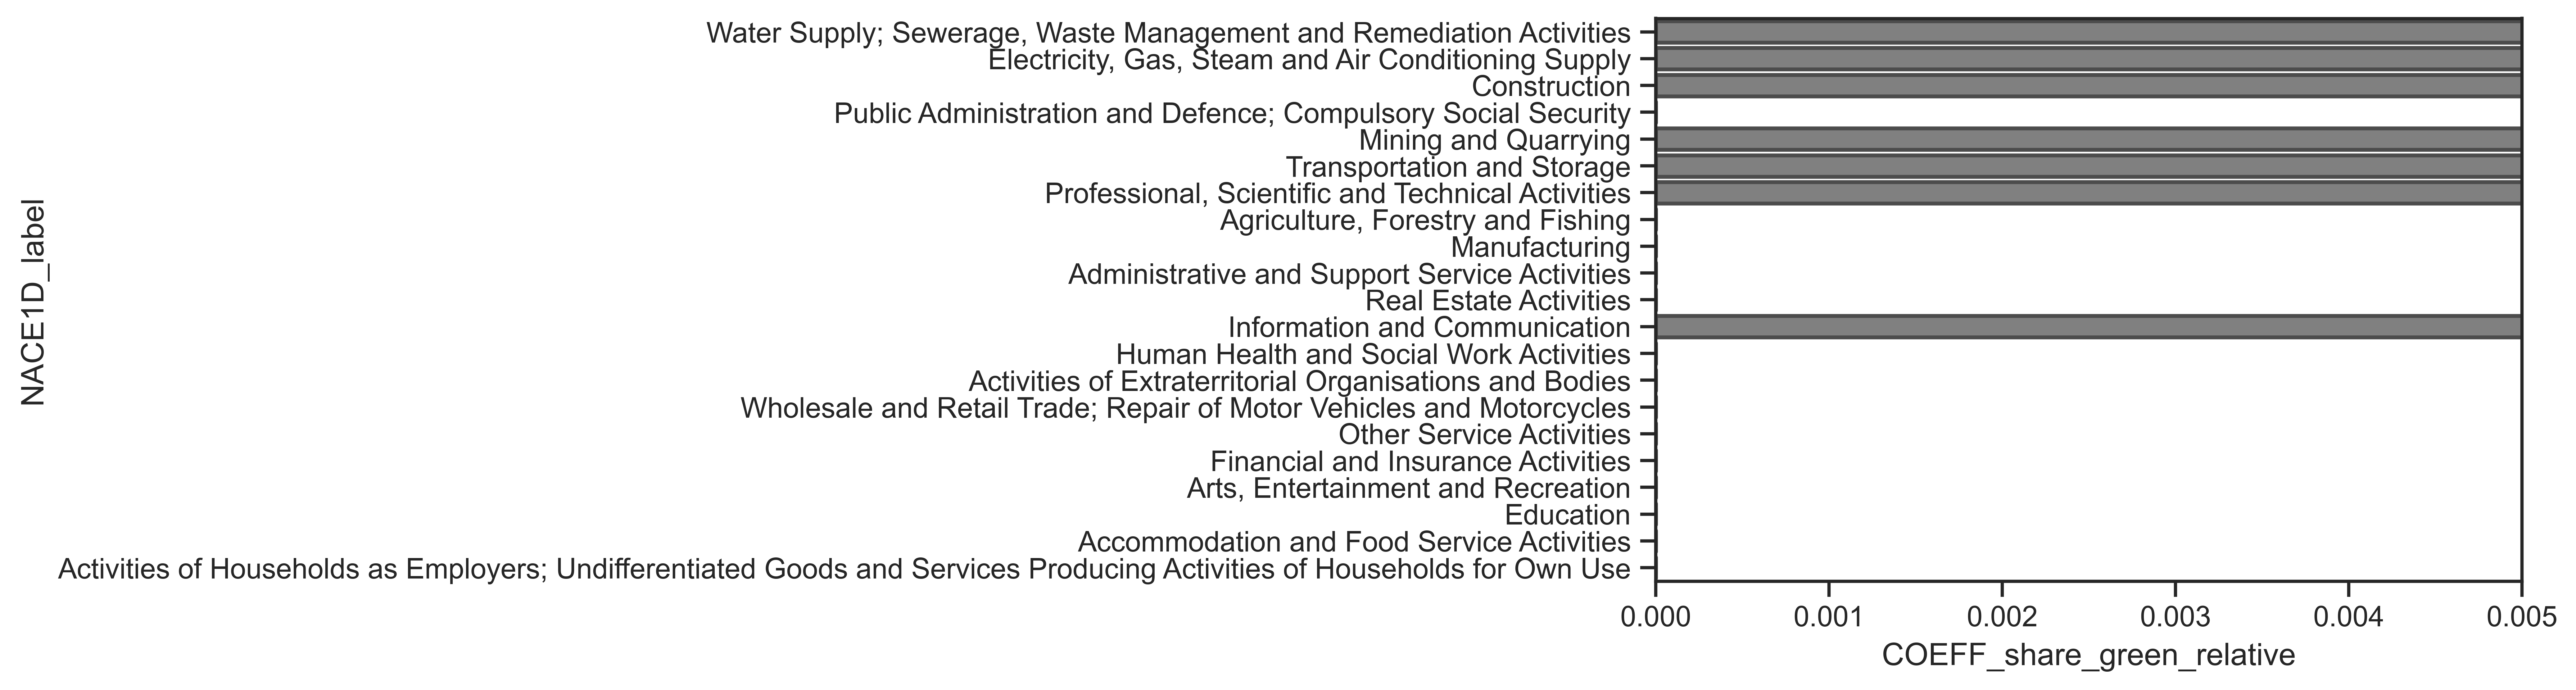

In [19]:
x = "COEFF_share_green_relative"
y = "NACE1D_label"

ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    order=df.groupby(y)[x].mean().sort_values(ascending=False).index.values,
    color=".5",
    fliersize=1,
    showfliers=True,
)

ax.set_xlim(0, 0.005)

df.groupby(y)[x].median()

Bar plots to also show absolute numbers

Our estimate of 212.5 Million compares well with the [offical size of labour force](https://data.worldbank.org/indicator/SL.TLF.TOTL.IN?locations=EU), 217.8 Million (some countries are missing in our estimates).

In [20]:
df.COEFF.sum()

212628832.805

##### Absolute/relative COEFF by industry and scenario
- https://stackoverflow.com/questions/72936696/plotting-ax-bar-label-on-sns-does-not-iterate-through-hue-appropriately

In [21]:
x_vars = [
    "COEFF_share_coal",
    "COEFF_share_brown_slt",
    "COEFF_share_brown_sl",
    "COEFF_share_green",
]

new_labels = ["CPO", "FFPOTC", "FFPO", "Green"]

relabel = dict(zip(x_vars, new_labels))
df = df.rename(columns=relabel)

In [22]:
df_long = pd.melt(
    df,
    value_vars=new_labels,
    id_vars=set(df.columns.values) - set(new_labels),
    var_name="Pool",
    value_name="Workers",
)

In [23]:
df_long

,share_neutral_slt,NACE1D,category_slt,WSTATOR,FTPT,DEGURBA,COEFF,COEFF_share_brown_slt_relative,COUNTRYW,category_sl,NACE1D_label_short,COEFF_share_brown_sl_relative,REGION,HATLEV1D,INCDECIL_median_floor,ISCO3D,NOBS,annual_earnings,AGE,COEFF_share_green_relative,decile,share_brown_slt,SEX,country_code,REGIONW,EDUC4WN,REFYEAR,share_neutral_sl,ISCO3D_label,isco_code,ILOSTAT,ISCO,COEFF_relative,HHTYPE,INCDECIL,INCDECIL_median,INCDECIL_median_ceil,country,NACE1D_label,COEFF_share_coal_relative,NUTS_ID,COEFF_share_neutral_slt,COEFF_share_neutral_sl,COUNTRY,MAINSTAT,paper_selection,share_green,share_brown_sl,INCDECIL_imputed,Pool,Workers
0,0.983051,C,neutral,1,1,3,82.5525,0.016949,AT,neutral,Manufacturing,0.033898,10,M,NaN,132,1.0,NaN,52,0.00,NaN,0.016949,1,NaN,12,0,2019,0.966102,"Manufacturing, mining, construction, and distr...",132,1,132,1.0,1,NaN,NaN,NaN,NaN,Manufacturing,NaN,AT12,81.153305,79.754110,AT,1,True,0.00,0.033898,NaN,CPO,NaN
1,0.983051,C,neutral,1,1,1,39.1925,0.016949,AT,neutral,Manufacturing,0.033898,20,H,NaN,132,1.0,NaN,57,0.00,NaN,0.016949,1,NaN,21,0,2019,0.966102,"Manufacturing, mining, construction, and distr...",132,1,132,1.0,1,NaN,NaN,NaN,NaN,Manufacturing,NaN,AT21,38.528220,37.863941,AT,1,True,0.00,0.033898,NaN,CPO,NaN
2,0.983051,C,neutral,1,1,3,76.8850,0.016949,AT,neutral,Manufacturing,0.033898,10,M,NaN,132,1.0,NaN,37,0.00,NaN,0.016949,1,NaN,31,0,2019,0.966102,"Manufacturing, mining, construction, and distr...",132,1,132,1.0,1,NaN,NaN,NaN,NaN,Manufacturing,NaN,AT31,75.581864,74.278729,AT,1,True,0.00,0.033898,NaN,CPO,NaN
3,0.983051,C,neutral,1,1,3,70.1975,0.016949,AT,neutral,Manufacturing,0.033898,30,M,NaN,132,1.0,NaN,47,0.00,NaN,0.016949,1,NaN,31,0,2019,0.966102,"Manufacturing, mining, construction, and distr...",132,1,132,1.0,1,NaN,NaN,NaN,NaN,Manufacturing,NaN,AT31,69.007712,67.817924,AT,1,True,0.00,0.033898,NaN,CPO,NaN
4,0.983051,C,neutral,1,1,2,25.4575,0.016949,AT,neutral,Manufacturing,0.033898,30,M,NaN,132,1.0,NaN,37,0.00,NaN,0.016949,1,NaN,34,0,2019,0.966102,"Manufacturing, mining, construction, and distr...",132,1,132,1.0,1,NaN,NaN,NaN,NaN,Manufacturing,NaN,AT34,25.026017,24.594534,AT,1,True,0.00,0.033898,NaN,CPO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649179,1.000000,M,neutral,1,1,2,272.6200,0.000000,UK,neutral,Profess. Activ.,0.000000,N0,H,8.0,751,1.0,NaN,52,0.00,8.0,0.000000,1,UK,N0,0,2019,1.000000,Food processing and related trades workers,751,1,751,1.0,1,8.0,8.0,8.0,United Kingdom,"Professional, Scientific and Technical Activities",NaN,UKN,272.620000,272.620000,UK,NaN,False,0.00,0.000000,8.0,Green,0.0000
5649180,1.000000,M,neutral,1,2,1,264.0200,0.000000,UK,neutral,Profess. Activ.,0.000000,N0,L,1.0,515,1.0,NaN,37,0.00,1.0,0.000000,2,UK,N0,0,2019,1.000000,Building and housekeeping supervisors,515,1,515,1.0,1,1.0,1.0,1.0,United Kingdom,"Professional, Scientific and Technical Activities",NaN,UKN,264.020000,264.020000,UK,NaN,False,0.00,0.000000,1.0,Green,0.0000
5649181,0.500000,E,brown,1,1,3,726.8300,0.500000,UK,brown,"Water, Waste Mgmt.",0.923077,H0,M,8.0,811,1.0,NaN,52,0.00,8.0,0.500000,1,UK,H0,0,2019,0.076923,Mining and mineral processing plant operators,811,1,811,1.0,1,8.0,8.0,8.0,United Kingdom,"Water Supply; Sewerage, Waste Management and R...",NaN,UKH,363.415000,55.910000,UK,NaN,True,0.00,0.923077,8.0,Green,0.0000
5649182,1.000000,Q,neutral,1,1,2,664.3200,0.000000,UK,neutral,"Health, Social",0.000000,F0,H,7.0,231,1.0,NaN,37,0.00,7.0,0.000000,2,UK,F0,0,2019,1.000000,University and higher education teachers,231,1,231,1.0,1,7.0,7.0,7.0,United Kingdom,Human Health and Social Work Activities,NaN,UKF,664.320000,664.320000,UK,NaN,False,0.00,0.000000,7.0,Green,0.0000


##### Sectoral distribution (2C)

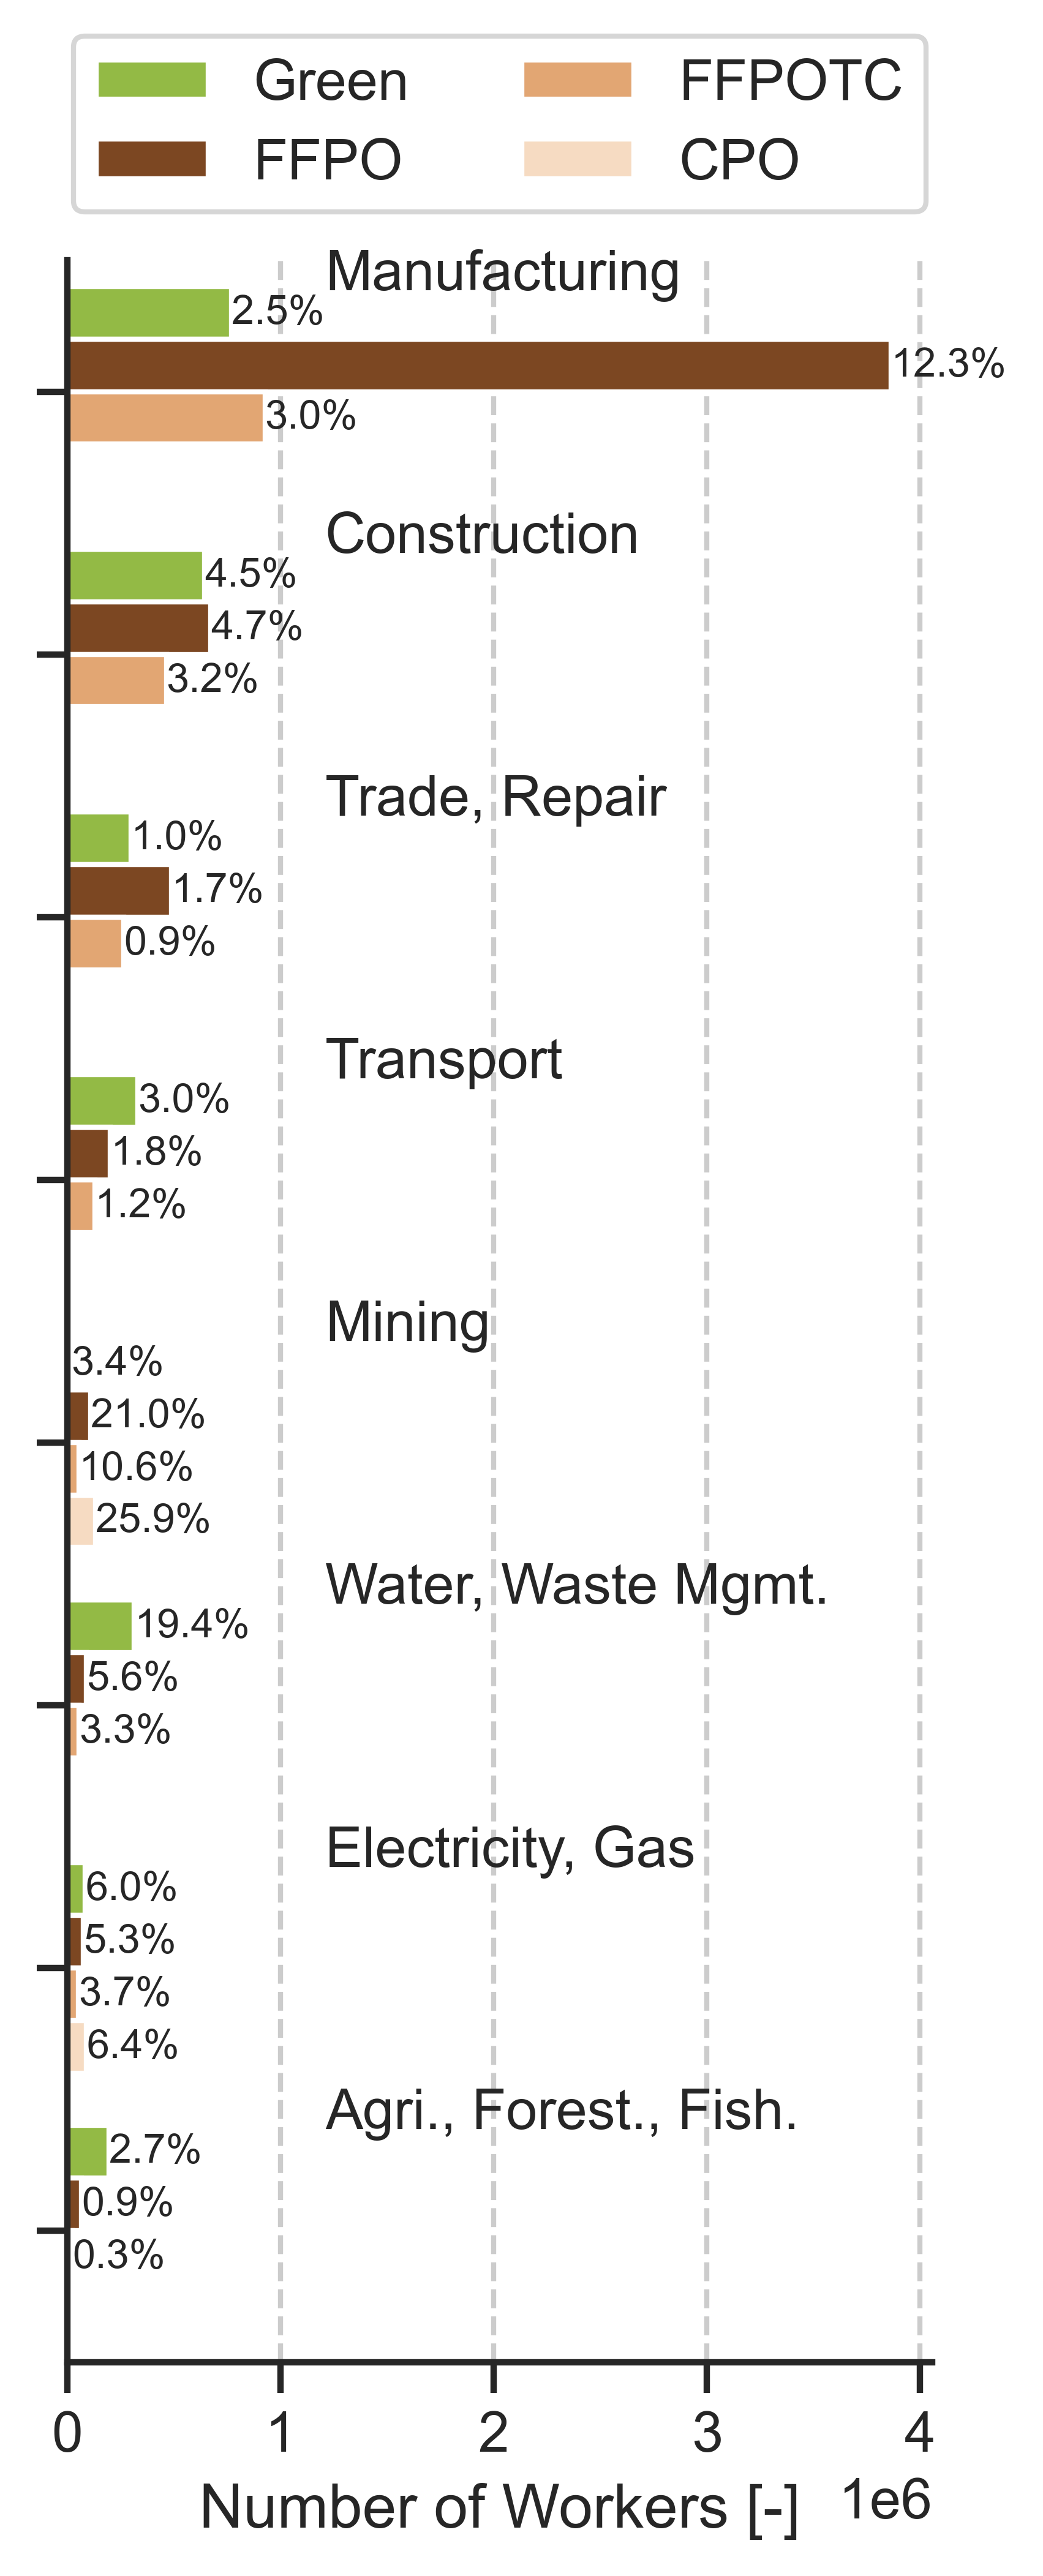

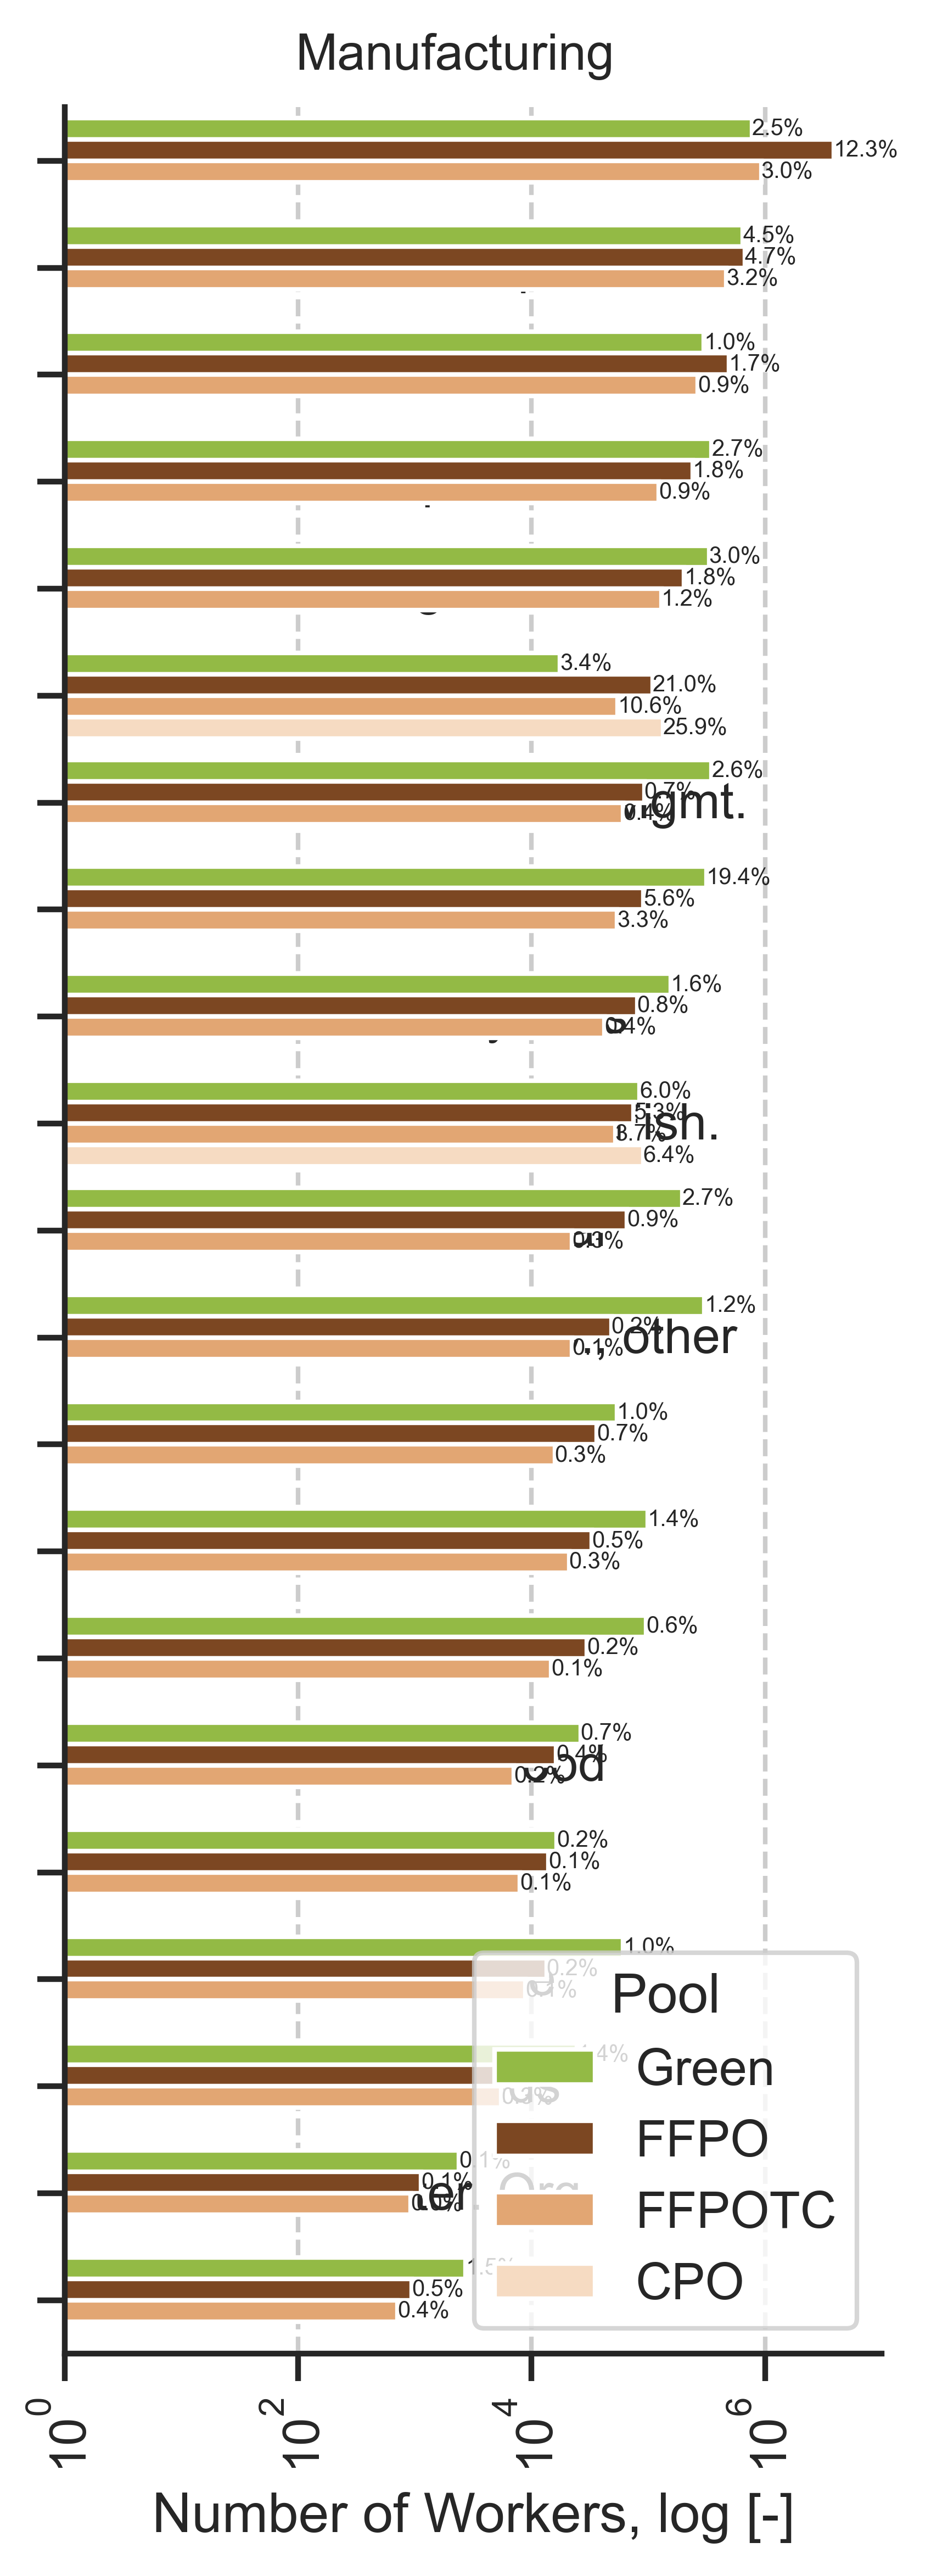

In [24]:
from src.plotting_utils import move_legend_to_right, move_legend_to_top

# params
x = "Workers"
y = "NACE1D_label_short"
hue = "Pool"
hue_order = ["Green", "FFPO", "FFPOTC", "CPO"]
dpi = 300
shift_ylabels_right = True
figsize = (5, 8) if not shift_ylabels_right else (3, 8)

# cmap
color_mapping = {
    "FFPO": "saddlebrown",
    "FFPOTC": "sandybrown",
    "CPO": "peachpuff",
    "Green": "yellowgreen",
}

cmap = mpl.colors.ListedColormap(colors=[color_mapping[pool] for pool in hue_order])

mpl.cm.register_cmap("mycolormap", cmap)
cpal = sns.color_palette("mycolormap", n_colors=4, desat=1)

# plot
for industry_subset in [True, False]:

    if industry_subset:
        df_sub = df.loc[df["paper_selection"]]
        df_long_sub = df_long.loc[df_long["paper_selection"]]

        fontsize = 8
        rotation = 0
        logscale = False
    else:
        df_sub = df
        df_long_sub = df_long
        logscale = True

        fontsize = 5
        rotation = 90

    industry_order = (
        df_sub.groupby(y)["FFPO"].sum().sort_values(ascending=False).index.values
    )

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=df_long_sub,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=industry_order,
        estimator=np.sum,
        ci=None,
        # width=0.8,
        palette=cpal,
        ax=ax,
    )

    # bar labels
    sum_across_cnt_share = df_long_sub.groupby([y, hue])[x].sum()
    sum_across_cnt = df_long_sub.groupby([y, hue])["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    ind_share.name = "employment_relative"
    ind_share = ind_share.reindex(industry_order, level=0)

    df_ind_share = ind_share.reset_index()
    df_ind_share["employment_absolute"] = sum_across_cnt_share.reindex(
        industry_order, level=0
    ).values
    df_ind_share["employment_relative_pc"] = (
        df_ind_share["employment_relative"].multiply(100).round(1)
    )
    df_ind_share["employment_relative_pc_labels"] = [
        "{}%".format(l) for l in df_ind_share["employment_relative_pc"]
    ]

    # one container per hue level
    for container in ax.containers:
        df_hue = df_ind_share.loc[df_ind_share[hue] == container.get_label()]
        ax.bar_label(
            container, labels=df_hue["employment_relative_pc_labels"], fontsize=fontsize
        )

    # layout
    if logscale:
        ax.set_xscale("log")
        ax.set_xlabel("Number of Workers, log [-]")
        plt.xlim(1, 10e6)
    else:
        ax.set_xlabel("Number of Workers [-]")

    if shift_ylabels_right:
        # Create offset transform by X points in x direction
        dx = 250 / dpi
        dy = 100 / dpi
        offset = mpl.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)

        # apply offset transform to all x ticklabels.
        for label in ax.yaxis.get_majorticklabels():
            label.set_horizontalalignment("left")
            label.set_transform(label.get_transform() + offset)

    # grid and labelling
    ax.grid(axis="x", which="major", linestyle="--", zorder=0)
    ax.set_ylabel(None)
    plt.xticks(rotation=rotation)

    sns.despine()
    plt.tight_layout()

    if industry_subset:
        move_legend_to_top(ax, ncol=2, lower_anchor=0.5, upper_anchor=1.12)

    # save
    out_path = os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_industry",
        "grouped_by_industry_only",
        "{}_by_{}_scenarios_subset_{}.{}",
    )
    plt.savefig(
        out_path.format(x, y, industry_subset, "png"),
        dpi=dpi,
        bbox_inches="tight",
    )
    df_ind_share.to_csv(
        out_path.format(x, y, industry_subset, "csv"),
    )

In [25]:
pd.options.display.float_format = "{:,.2f}".format
df_ind_share

,NACE1D_label_short,Pool,employment_relative,employment_absolute,employment_relative_pc,employment_relative_pc_labels
0,Manufacturing,CPO,0.00,0.00,0.00,0.0%
1,Manufacturing,FFPO,0.12,"3,862,851.55",12.30,12.3%
2,Manufacturing,FFPOTC,0.03,"927,143.70",3.00,3.0%
3,Manufacturing,Green,0.02,"770,115.81",2.50,2.5%
4,Construction,CPO,0.00,0.00,0.00,0.0%
5,Construction,FFPO,0.05,"671,177.74",4.70,4.7%
6,Construction,FFPOTC,0.03,"464,150.04",3.20,3.2%
7,Construction,Green,0.04,"643,857.71",4.50,4.5%
8,"Trade, Repair",CPO,0.00,0.00,0.00,0.0%
9,"Trade, Repair",FFPO,0.02,"488,165.45",1.70,1.7%


##### Absolute/relative COEFF by industry

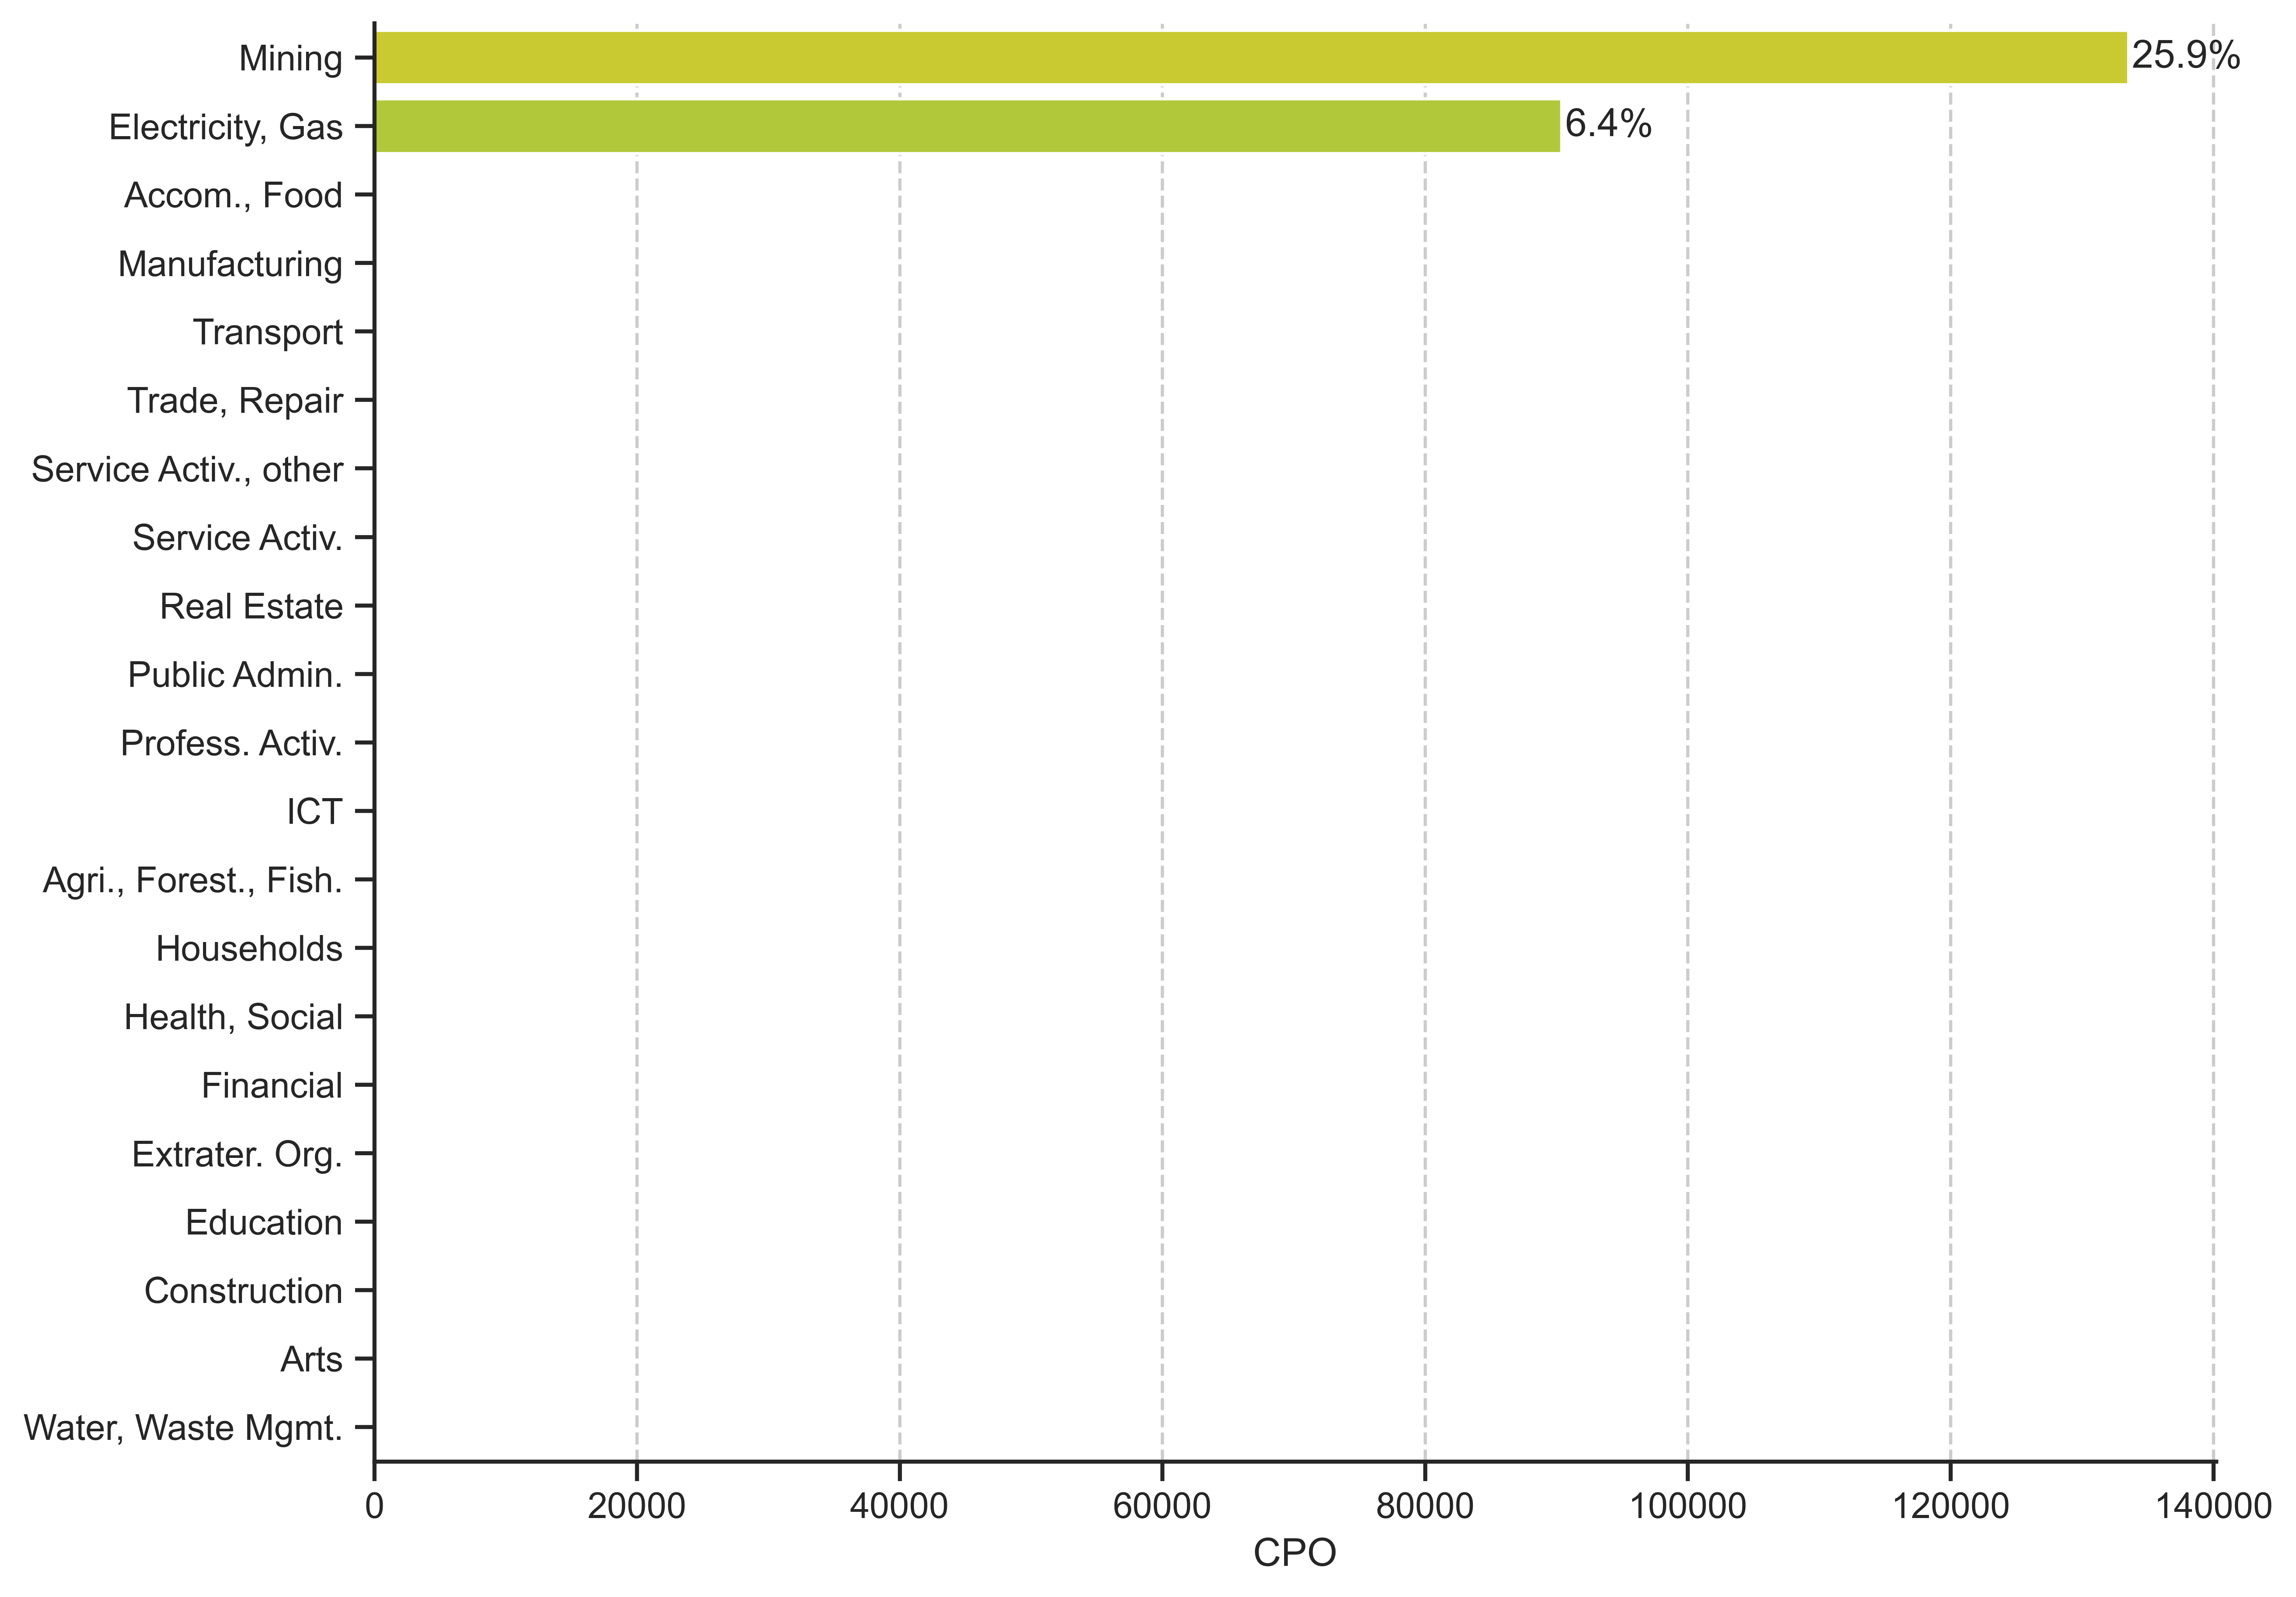

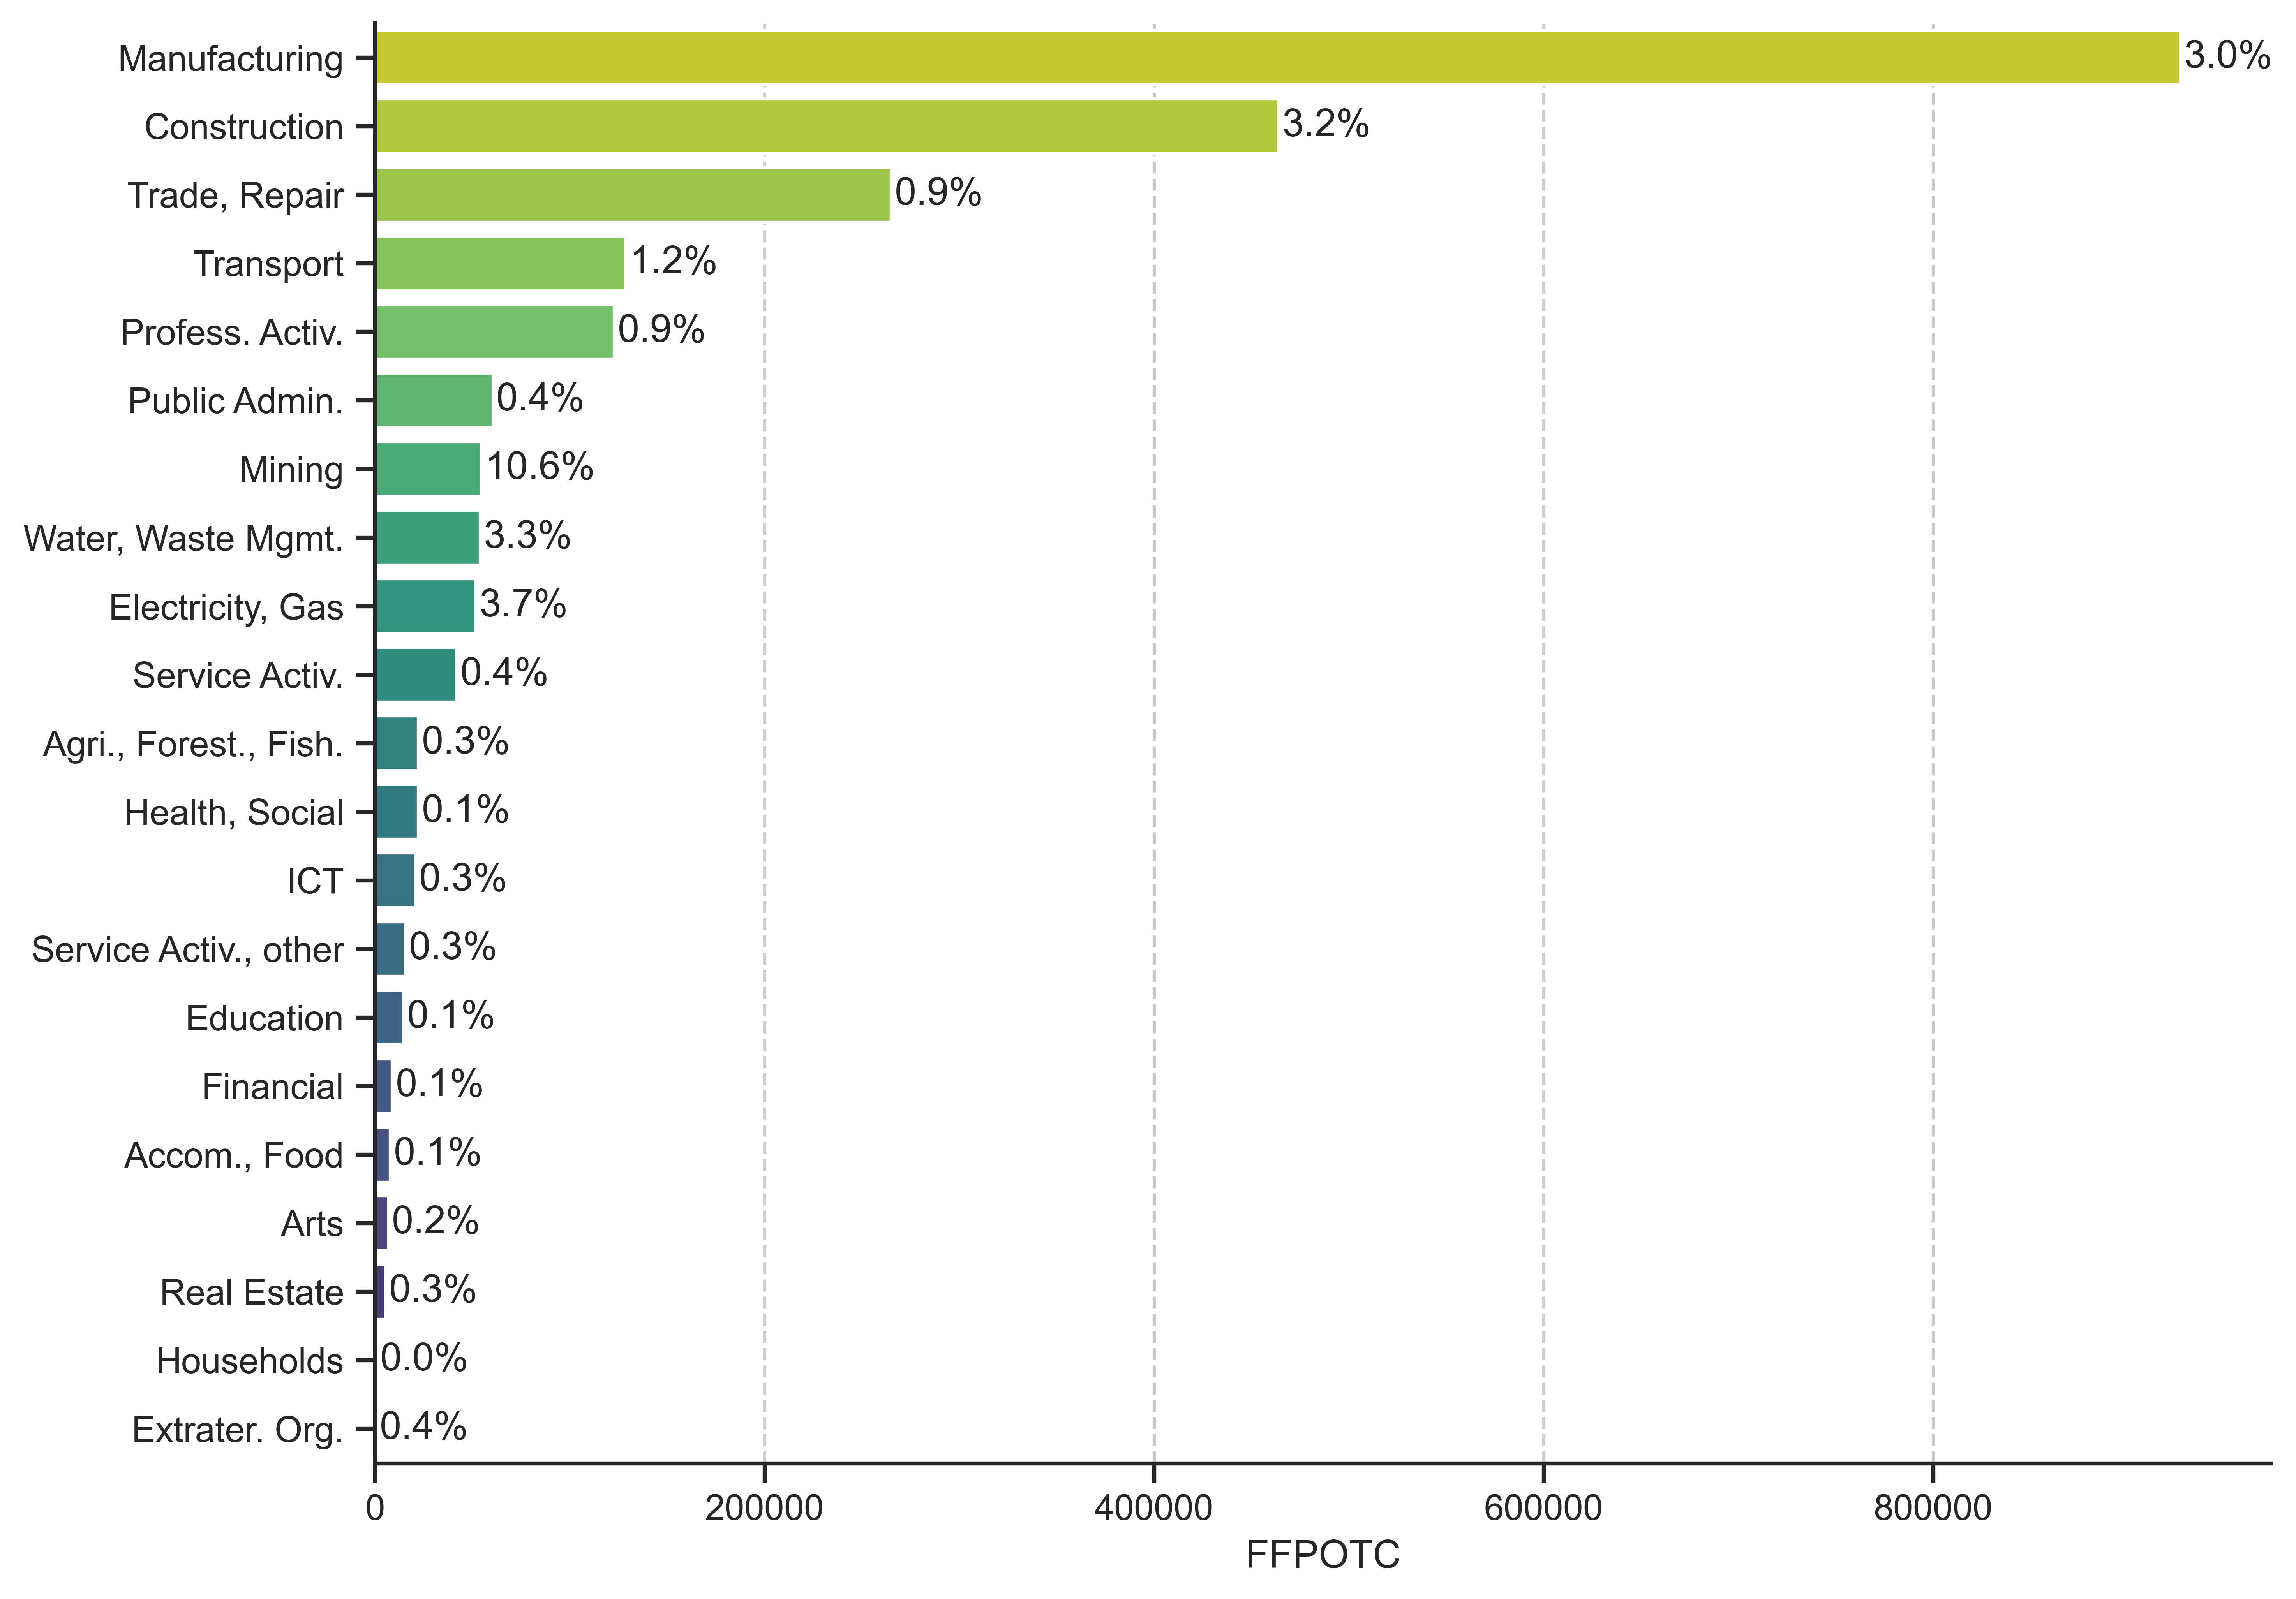

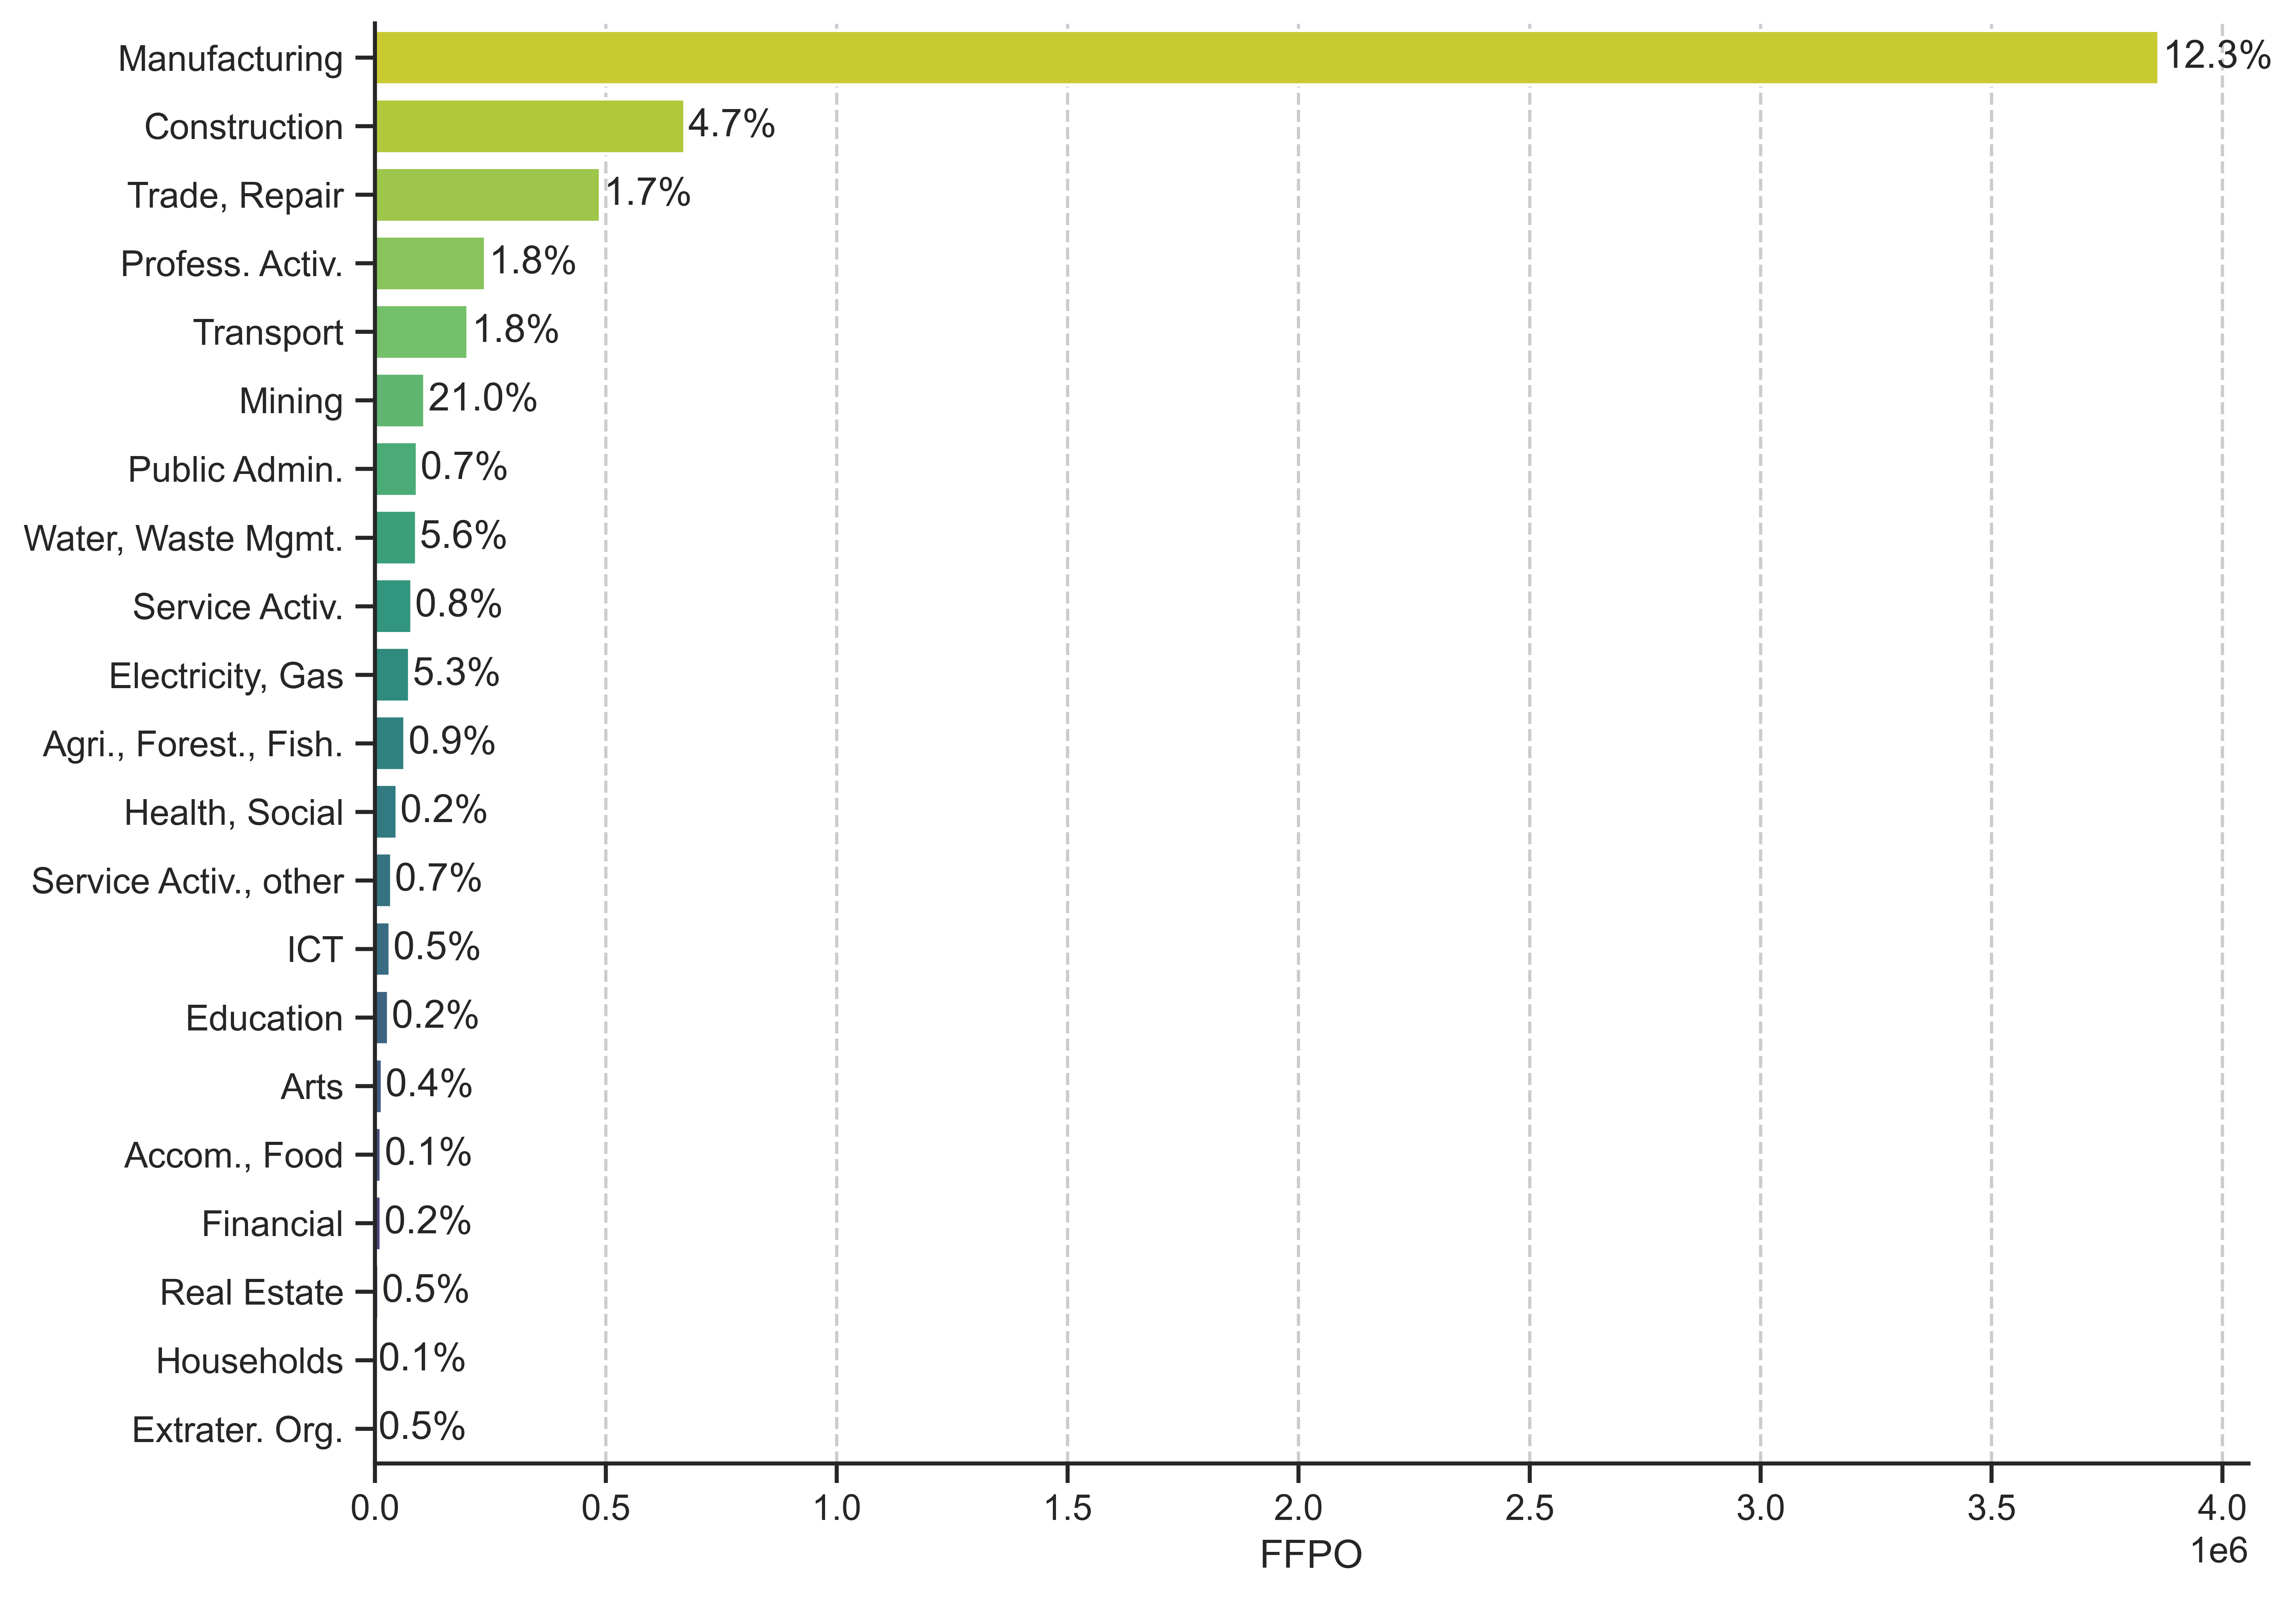

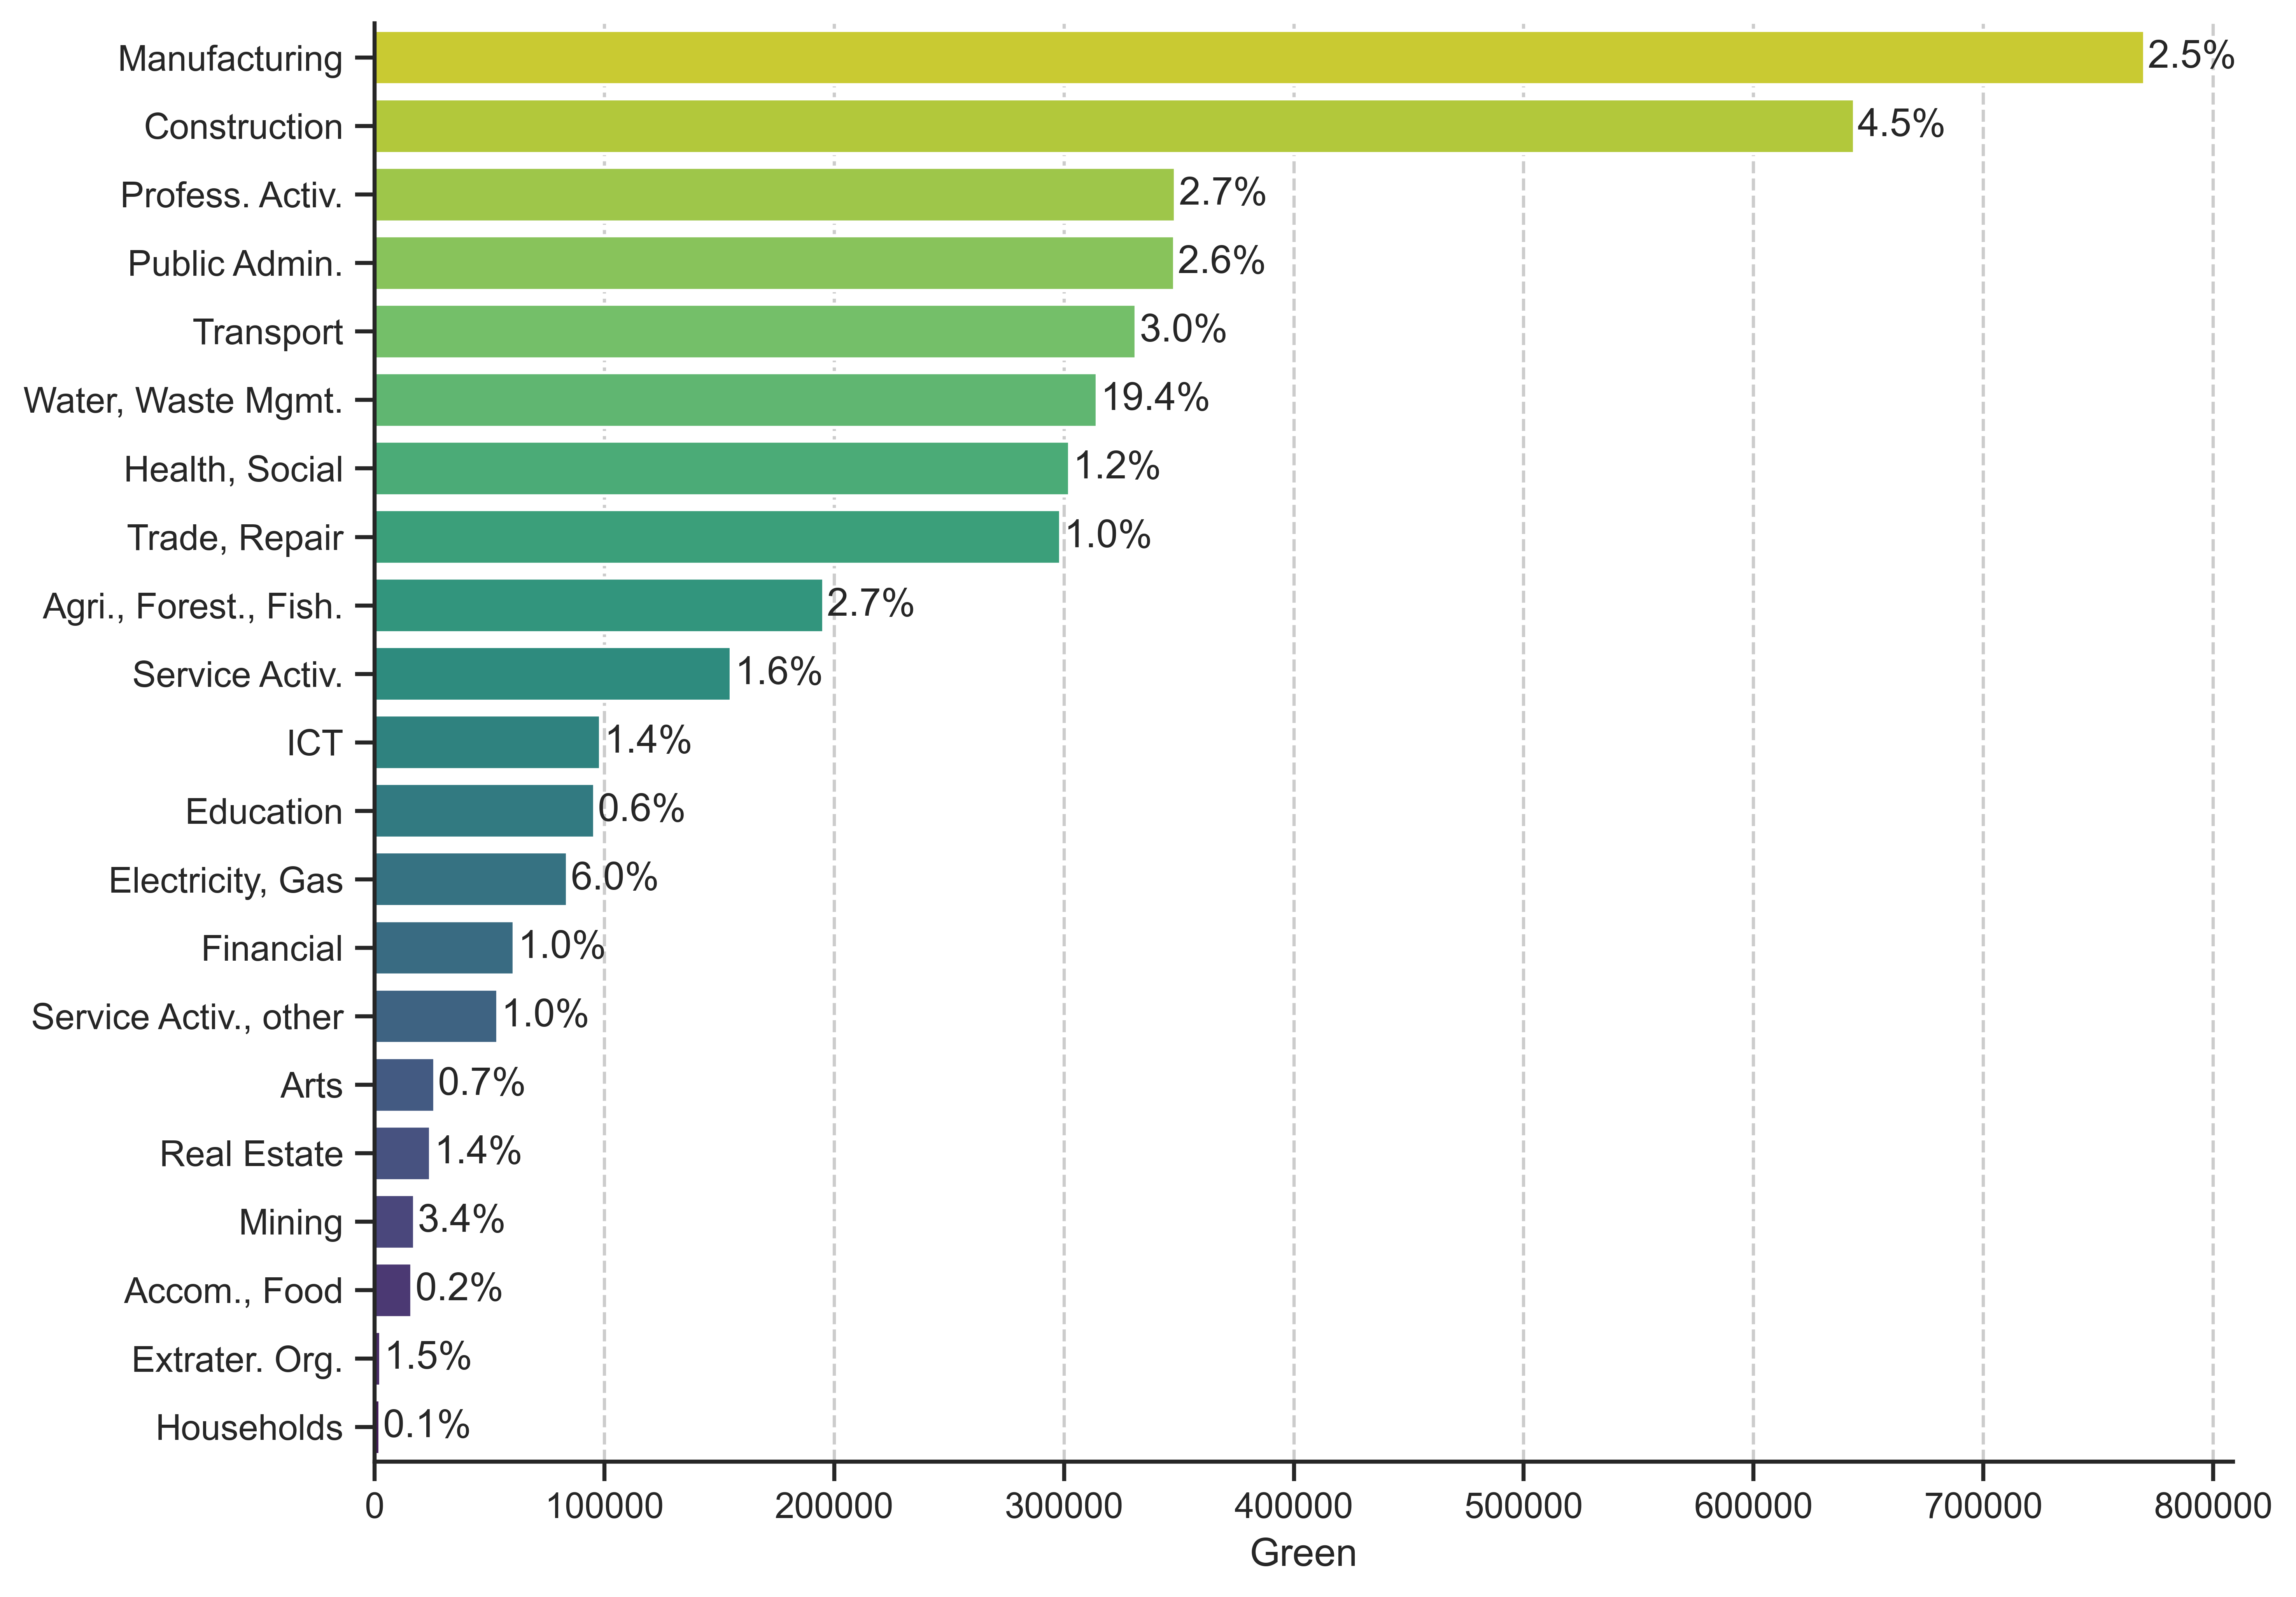

In [26]:
y = "NACE1D_label_short"

for x in new_labels:
    f, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(
        data=df,
        x=x,
        y=y,
        order=df.groupby(y)[x].sum().sort_values(ascending=False).index.values,
        estimator=np.sum,
        ci=None,
        palette="viridis_r",
        ax=ax,
    )

    # calculate sector-level percentage
    order = df.groupby(y)[x].sum().sort_values(ascending=False).index
    sum_across_cnt_share = df.groupby(y)[x].sum()
    sum_across_cnt = df.groupby(y)["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    percentages = ind_share.reindex(order).multiply(100).round(1)
    percent_labels = ["{}%".format(l) for l in percentages]

    # show the percentage within sector
    ax.bar_label(ax.containers[0], labels=percent_labels, padding=1)
    ax.set_ylabel(None)

    ax.grid(axis="x", linestyle="--", zorder=0)
    sns.despine()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "03_eulfs",
            "2019",
            "employment_shares_by_industry",
            "grouped_by_industry_only",
            "{}_by_{}_absolute.png".format(x, y),
        ),
        dpi=150,
    )
    # plt.clf()

Absolute/relative COEFF by country (OLD plot)

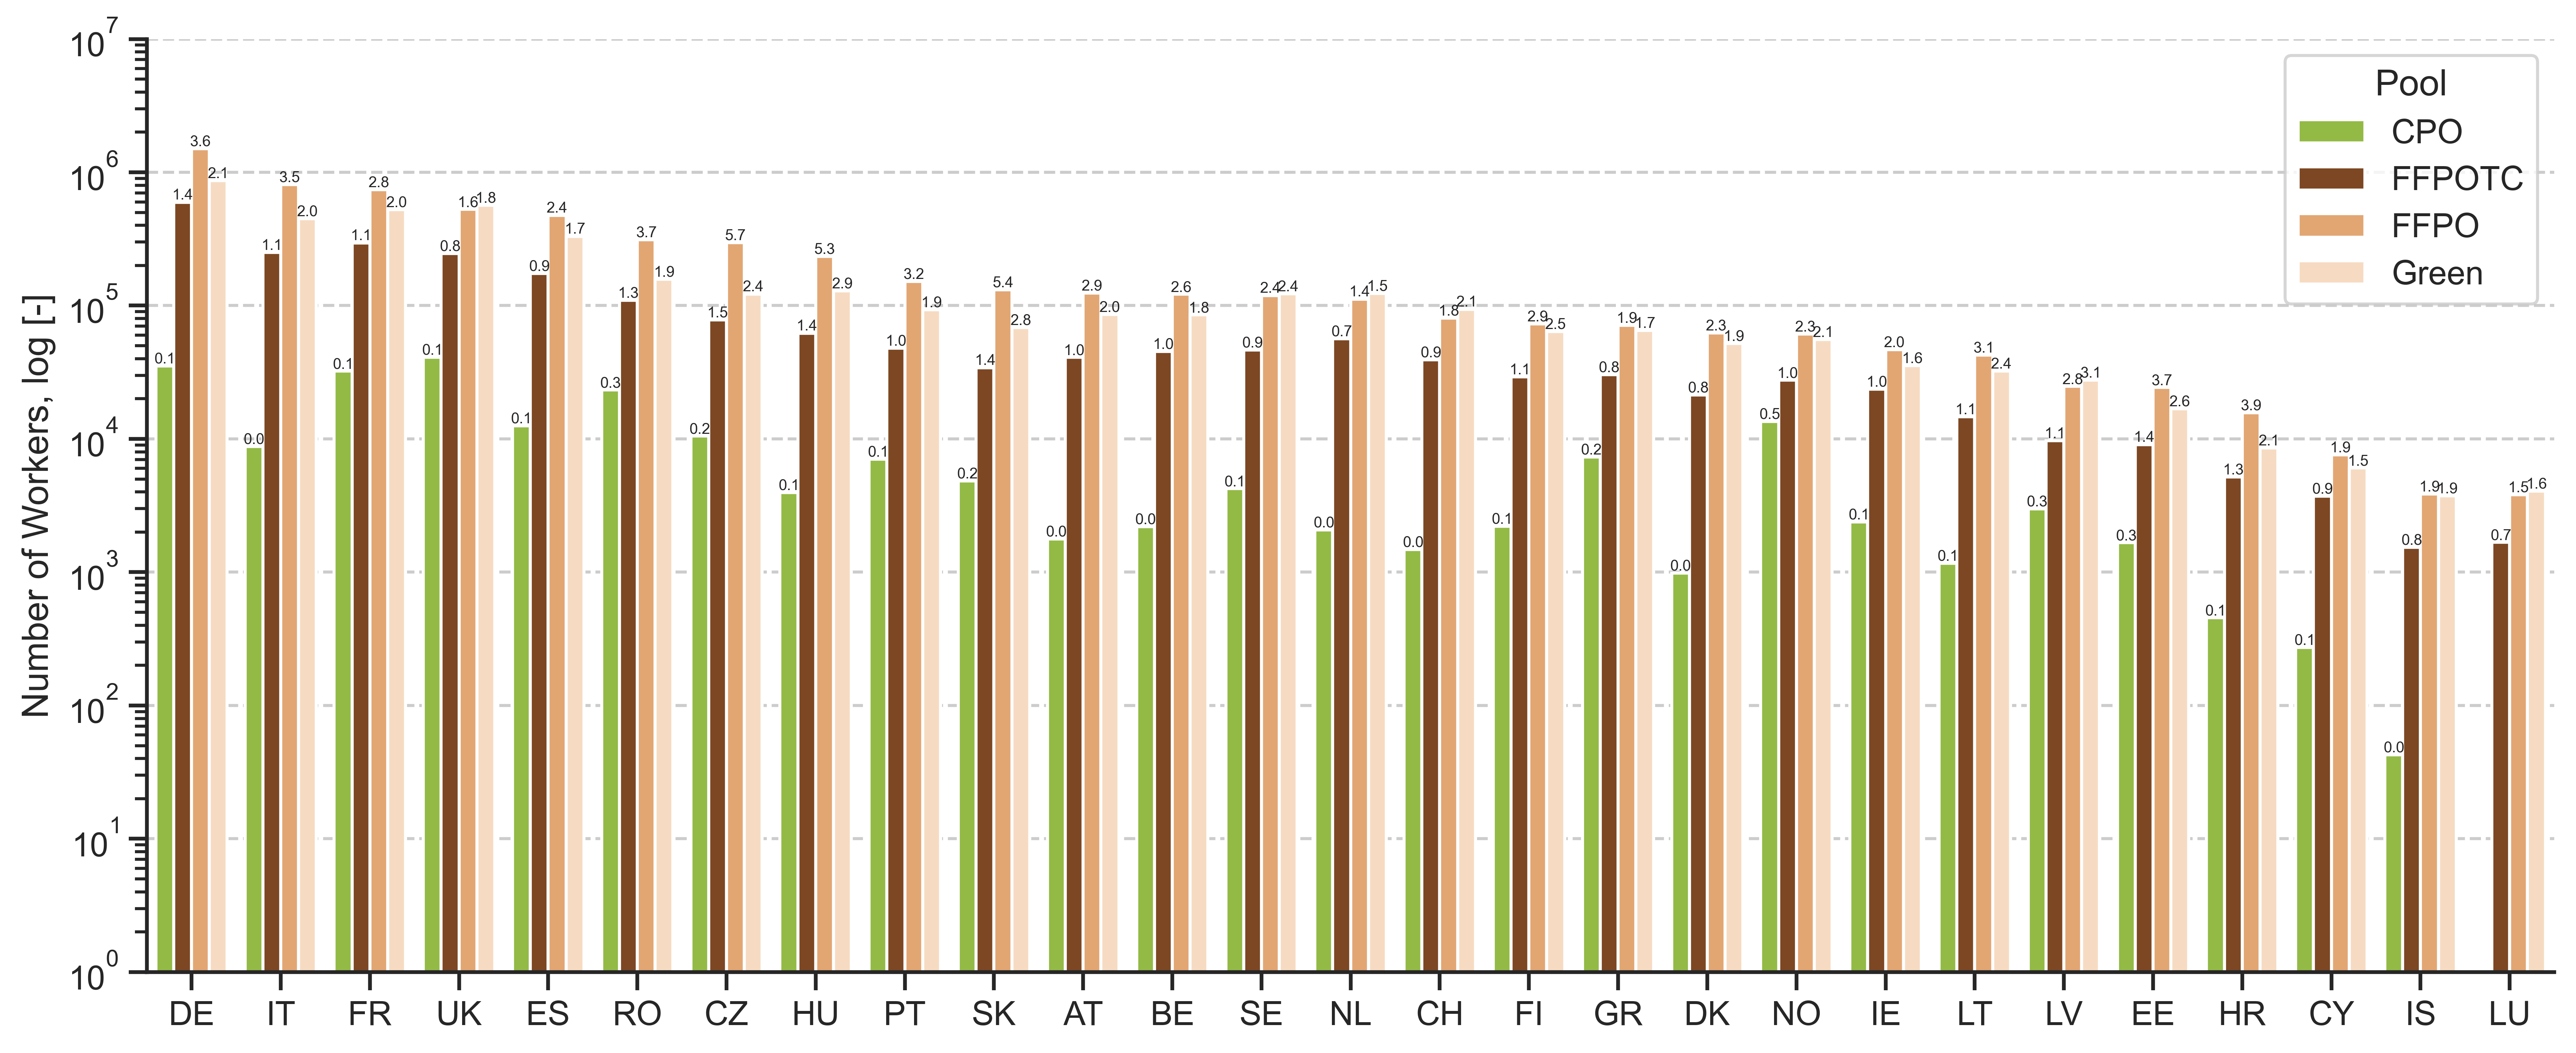

In [27]:
# params
x = "Workers"
y = "COUNTRYW"
hue = "Pool"

industry_order = df.groupby(y)["FFPO"].sum().sort_values(ascending=False).index.values

# plot
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=df_long,
    x=y,
    y=x,
    hue=hue,
    order=industry_order,
    estimator=np.sum,
    ci=None,
    palette=cpal,
    ax=ax,
)

# bar labels
sum_across_cnt_share = df_long.groupby([y, hue])[x].sum()
sum_across_cnt = df_long.groupby([y, hue])["COEFF"].sum()
cnt_share = sum_across_cnt_share.divide(sum_across_cnt).multiply(100)
cnt_share.name = "employment_relative"
cnt_share = cnt_share.reindex(industry_order, level=0)
sum_across_cnt_share = sum_across_cnt_share.reindex(industry_order, level=0)

df_cnt_share = cnt_share.reset_index()
df_cnt_share["percentages"] = df_cnt_share["employment_relative"].round(1)
df_cnt_share["percent_labels"] = ["{}".format(l) for l in df_cnt_share["percentages"]]
df_cnt_share["employment_absolute"] = sum_across_cnt_share.values

# one container per hue level
for container in ax.containers:
    df_hue = df_cnt_share.loc[df_cnt_share[hue] == container.get_label()]
    ax.bar_label(container, labels=df_hue["percent_labels"], fontsize=5)

# layout
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", zorder=0)

ax.set_ylabel("Number of Workers, log [-]")
ax.set_xlabel(None)

# plt.yticks(rotation=90)
plt.ylim(1, 10e6)
sns.despine()

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "{}_by_{}_scenarios.png".format(x, y),
    ),
    dpi=300,
)

##### Quadrant style: abs vs rel impact

##### Version 1 (With Green)

In [28]:
country_means = df_cnt_share.groupby("Pool").mean()
country_means

,employment_relative,percentages,employment_absolute
Pool,,,
CPO,0.13,0.12,"8,294.45"
FFPO,2.91,2.91,"228,730.80"
FFPOTC,1.05,1.05,"85,122.81"
Green,2.08,2.09,"155,199.44"


In [29]:
df_cnt_share.drop(columns=["percentages", "percent_labels"]).to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "employment_abs_rel_by_country.csv",
    )
)

In [30]:
df_cnt_share

,COUNTRYW,Pool,employment_relative,percentages,percent_labels,employment_absolute
0,DE,CPO,0.08,0.10,0.1,"35,190.17"
1,DE,FFPO,3.61,3.60,3.6,"1,506,568.44"
2,DE,FFPOTC,1.43,1.40,1.4,"596,274.52"
3,DE,Green,2.08,2.10,2.1,"866,581.70"
4,IT,CPO,0.04,0.00,0.0,"8,780.52"
5,IT,FFPO,3.53,3.50,3.5,"808,979.14"
6,IT,FFPOTC,1.09,1.10,1.1,"250,332.43"
7,IT,Green,1.96,2.00,2.0,"449,234.31"
8,FR,CPO,0.12,0.10,0.1,"32,189.78"
9,FR,FFPO,2.83,2.80,2.8,"739,656.09"


##### Version 2 (w/o Green)

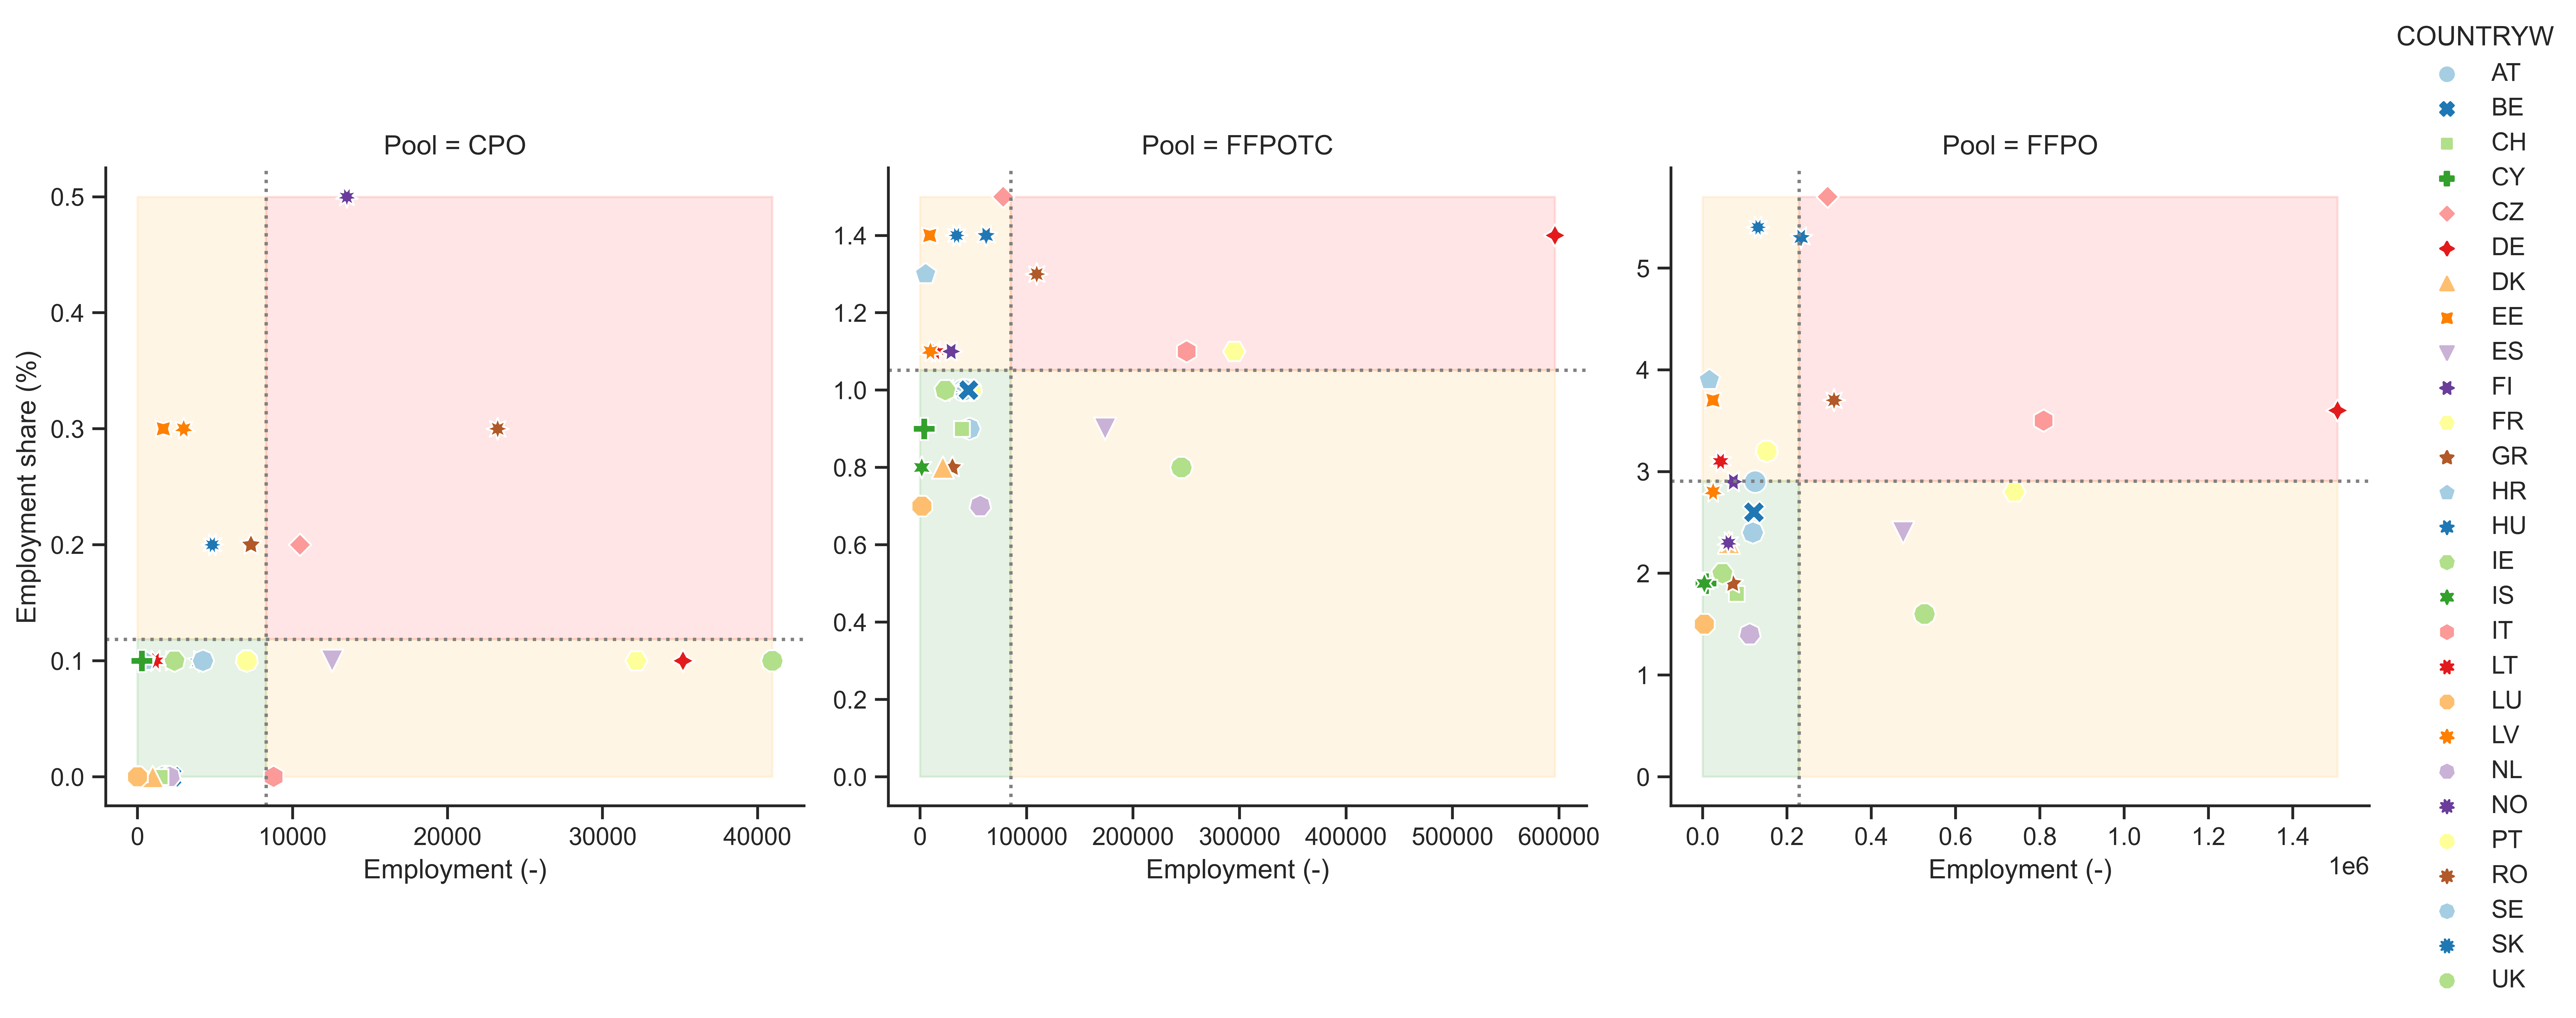

In [31]:
facet_kws = {"sharey": False, "sharex": False}
col_order = ["CPO", "FFPOTC", "FFPO"]
fill_alpha = 0.1

g = sns.relplot(
    data=df_cnt_share.loc[df_cnt_share["Pool"] != "Green"],
    x="employment_absolute",
    y="percentages",
    col="Pool",
    col_order=col_order,
    hue="COUNTRYW",
    style="COUNTRYW",
    palette="Paired",
    kind="scatter",
    col_wrap=3,
    s=100,
    facet_kws=facet_kws,
)

# annotate means
for i, (ax, pool) in enumerate(zip(g.axes, col_order)):

    # draw means
    x_mean = country_means.loc[pool, "employment_absolute"]
    y_mean = country_means.loc[pool, "percentages"]

    ax.axvline(x_mean, color="grey", linestyle=":")
    ax.axhline(y_mean, color="grey", linestyle=":")

    # fill areas
    x = df_cnt_share.loc[df_cnt_share["Pool"] == pool, "employment_absolute"]
    y = df_cnt_share.loc[df_cnt_share["Pool"] == pool, "percentages"]

    # low-risk
    ax.fill_between(
        x=[0, x_mean], y1=0, y2=y_mean, color="green", alpha=fill_alpha, zorder=0
    )
    # high-risk
    ax.fill_between(
        x=[x_mean, np.max(x)],
        y1=y_mean,
        y2=np.max(y),
        color="red",
        alpha=fill_alpha,
        zorder=0,
    )
    # mid-risk
    ax.fill_between(
        x=[0, x_mean],
        y1=y_mean,
        y2=np.max(y),
        color="orange",
        alpha=fill_alpha,
        zorder=0,
    )
    ax.fill_between(
        x=[x_mean, np.max(x)],
        y1=0,
        y2=y_mean,
        color="orange",
        alpha=fill_alpha,
        zorder=0,
    )

    # labels
    ax.set_xlabel("Employment (-)")
    if i == 0:
        ax.set_ylabel("Employment share (%)")

# sns.move_legend(g, loc="center right", ncol=2, bbox_to_anchor=(1.03, 0.5), frameon=True)
# plt.tight_layout()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "transition_risk_indicator_short.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [32]:
y = "COUNTRYW"

for x in new_labels:
    f, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(
        data=df,
        x=y,
        y=x,
        order=df.groupby(y)[x].sum().sort_values(ascending=False).index.values,
        estimator=np.sum,
        ci=None,
        color="Grey",
    )

    # calculate country-level percentage
    sum_across_cnt_share = df.groupby(y)[x].sum()
    sum_across_cnt = df.groupby(y)["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    order = sum_across_cnt_share.sort_values(ascending=False).index
    percentages = ind_share.reindex(order).multiply(100).round(1)
    percent_labels = ["{}%".format(l) for l in percentages]

    # show the percentage within sector
    ax.bar_label(ax.containers[0], labels=percent_labels, padding=1)

    ax.ticklabel_format(useOffset=False, style="plain", axis="y")
    ax.grid(axis="y", linestyle="--", zorder=0)
    sns.despine()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "03_eulfs",
            "2019",
            "employment_shares_by_country",
            "{}_by_{}_absolute.png".format(x, y),
        ),
        dpi=150,
    )
    plt.close(f)

Absolute/relative COEFF at EU level

CPO 223950.21999999997 0.10532448353576898
FFPOTC 2298315.9686607267 1.080905133297934
FFPO 6175731.603619292 2.904465740675443
Green 4190384.7590320623 1.9707509577852156


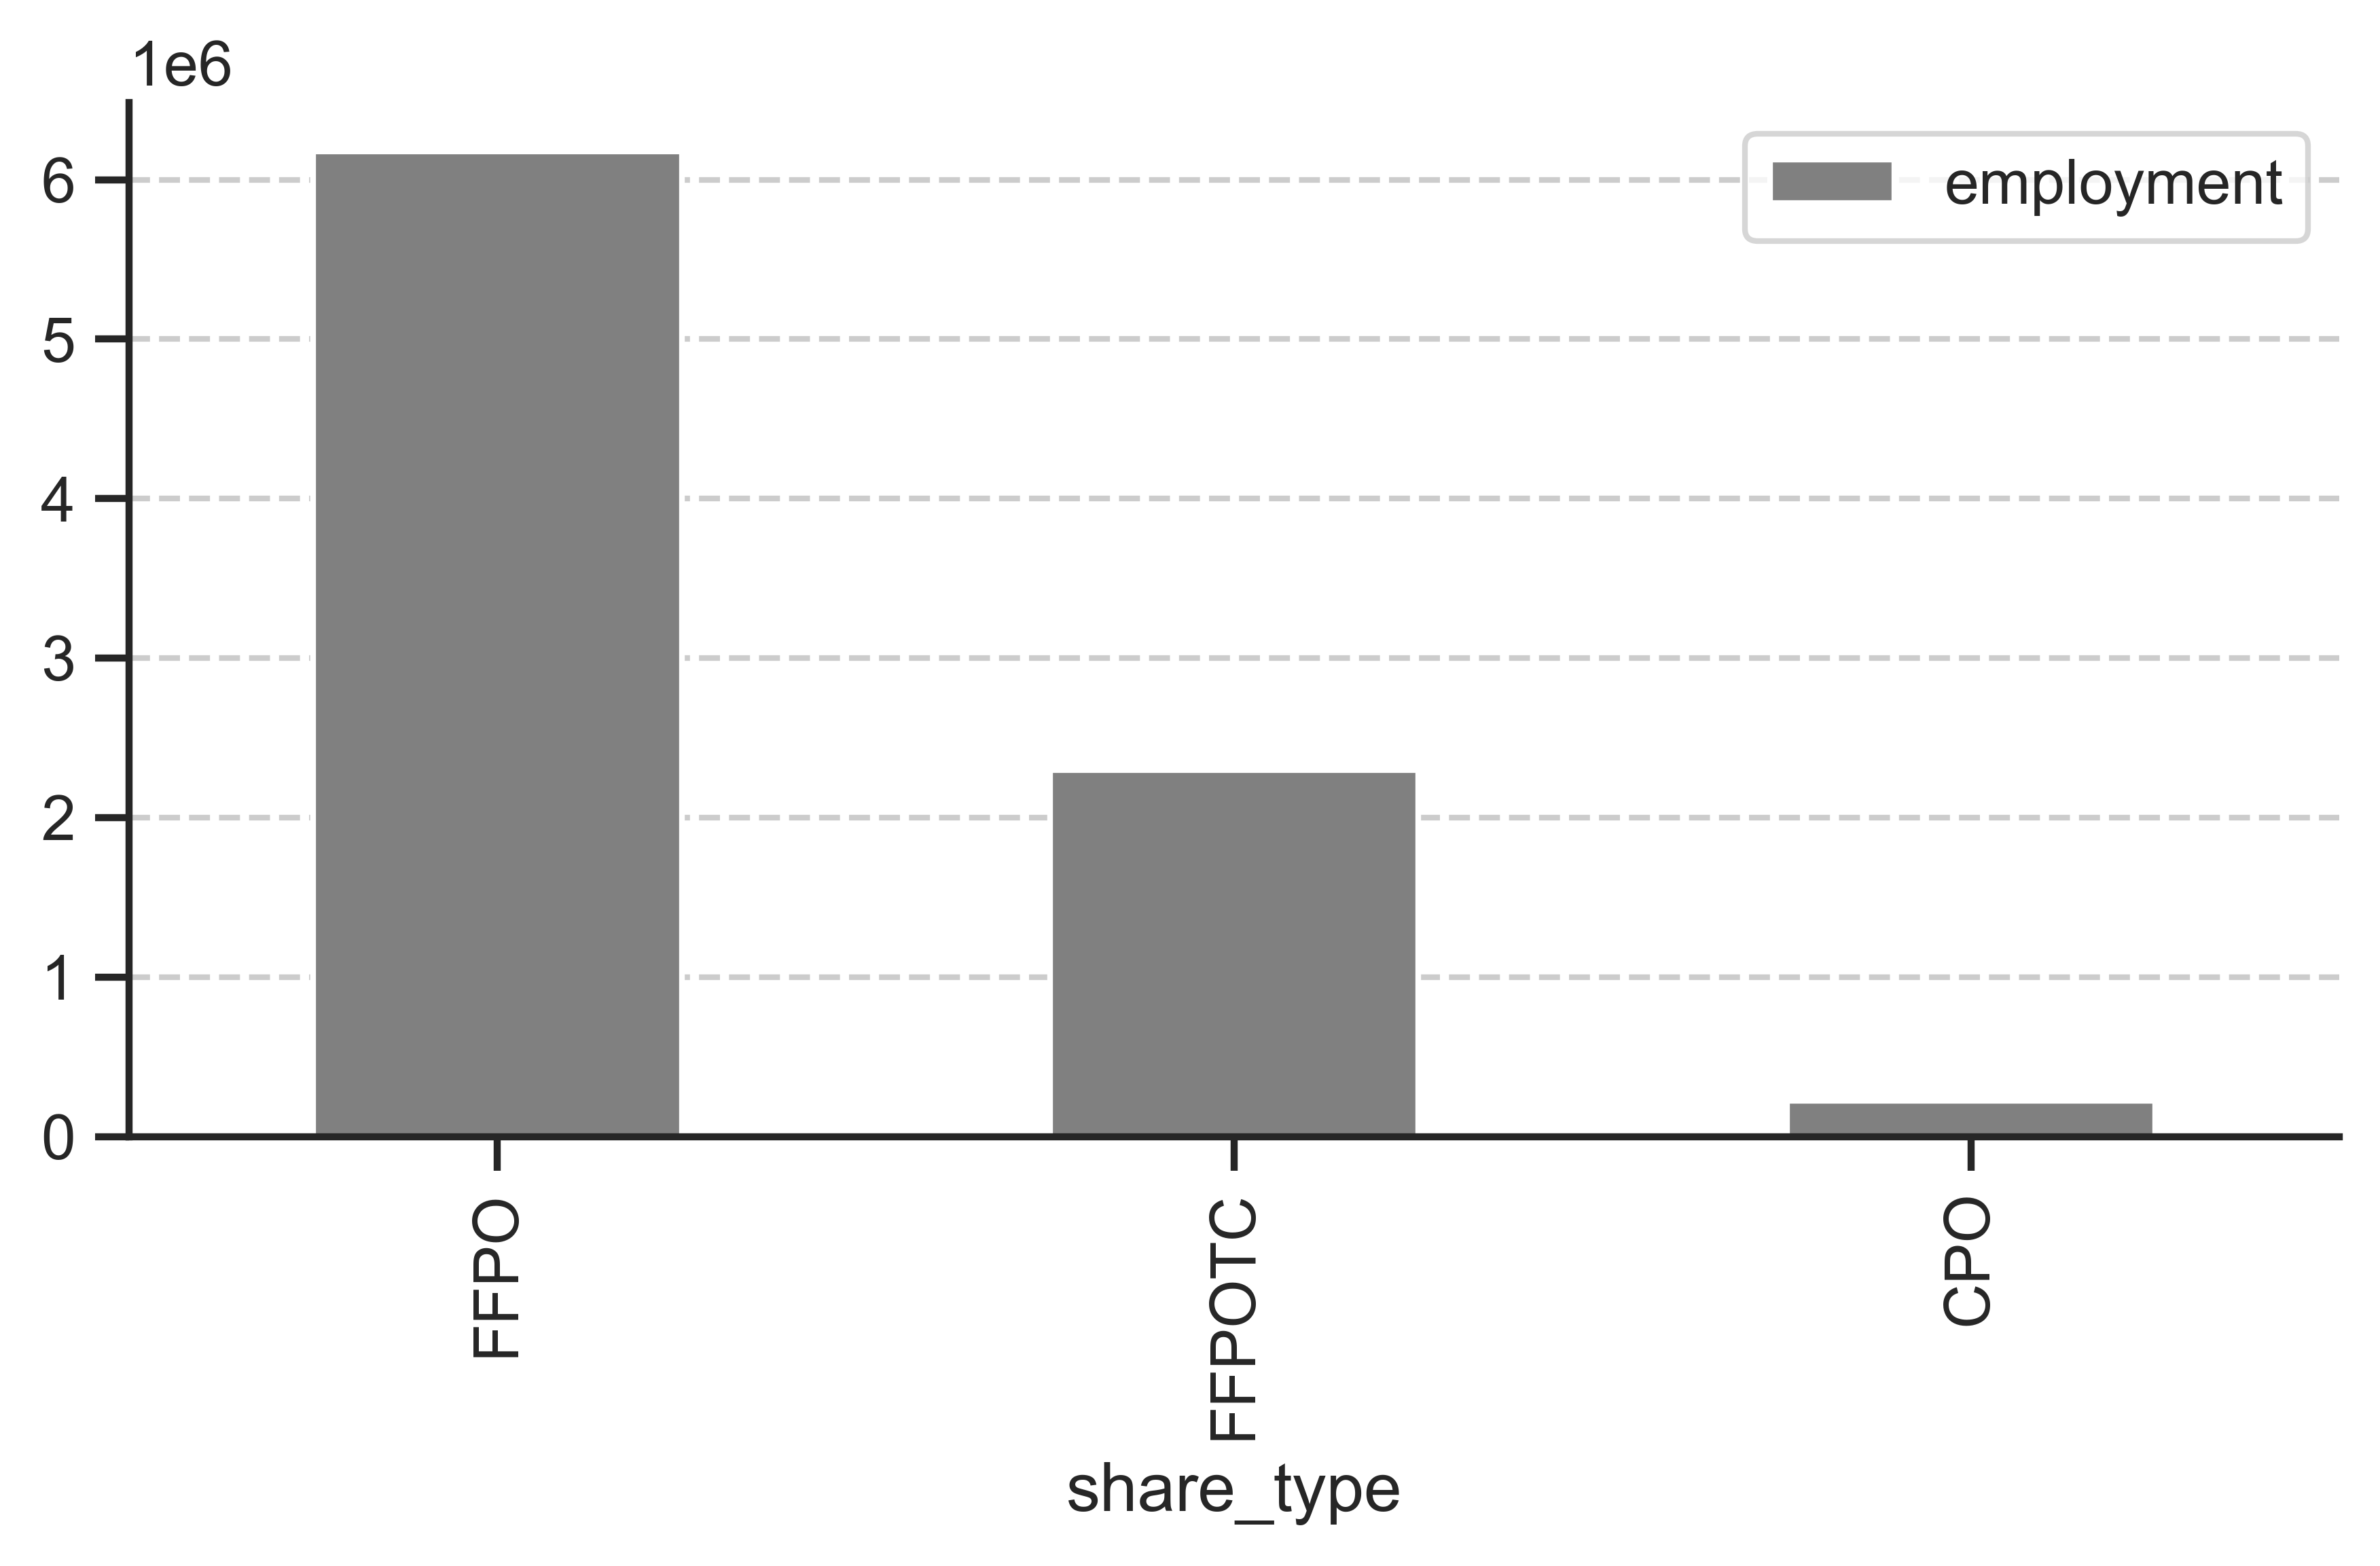

In [33]:
res = []
for x in new_labels:
    sum_total = df[x].sum()
    print(x, sum_total, 100 * (sum_total / df["COEFF"].sum()))
    res.append([x, sum_total])

df_res = pd.DataFrame(res, columns=["share_type", "employment"])
df_res = df_res.set_index("share_type")
ax = (
    df_res.iloc[0:3, :]
    .sort_values(by="employment", ascending=False)
    .plot.bar(color="grey")
)

ax.grid(axis="y", linestyle="--", zorder=0)
sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "EU_employment_by_share_type_absolute.png".format(x, y),
    ),
    dpi=300,
)

df_res.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "EU_employment_by_share_type_absolute.csv",
    ),
)

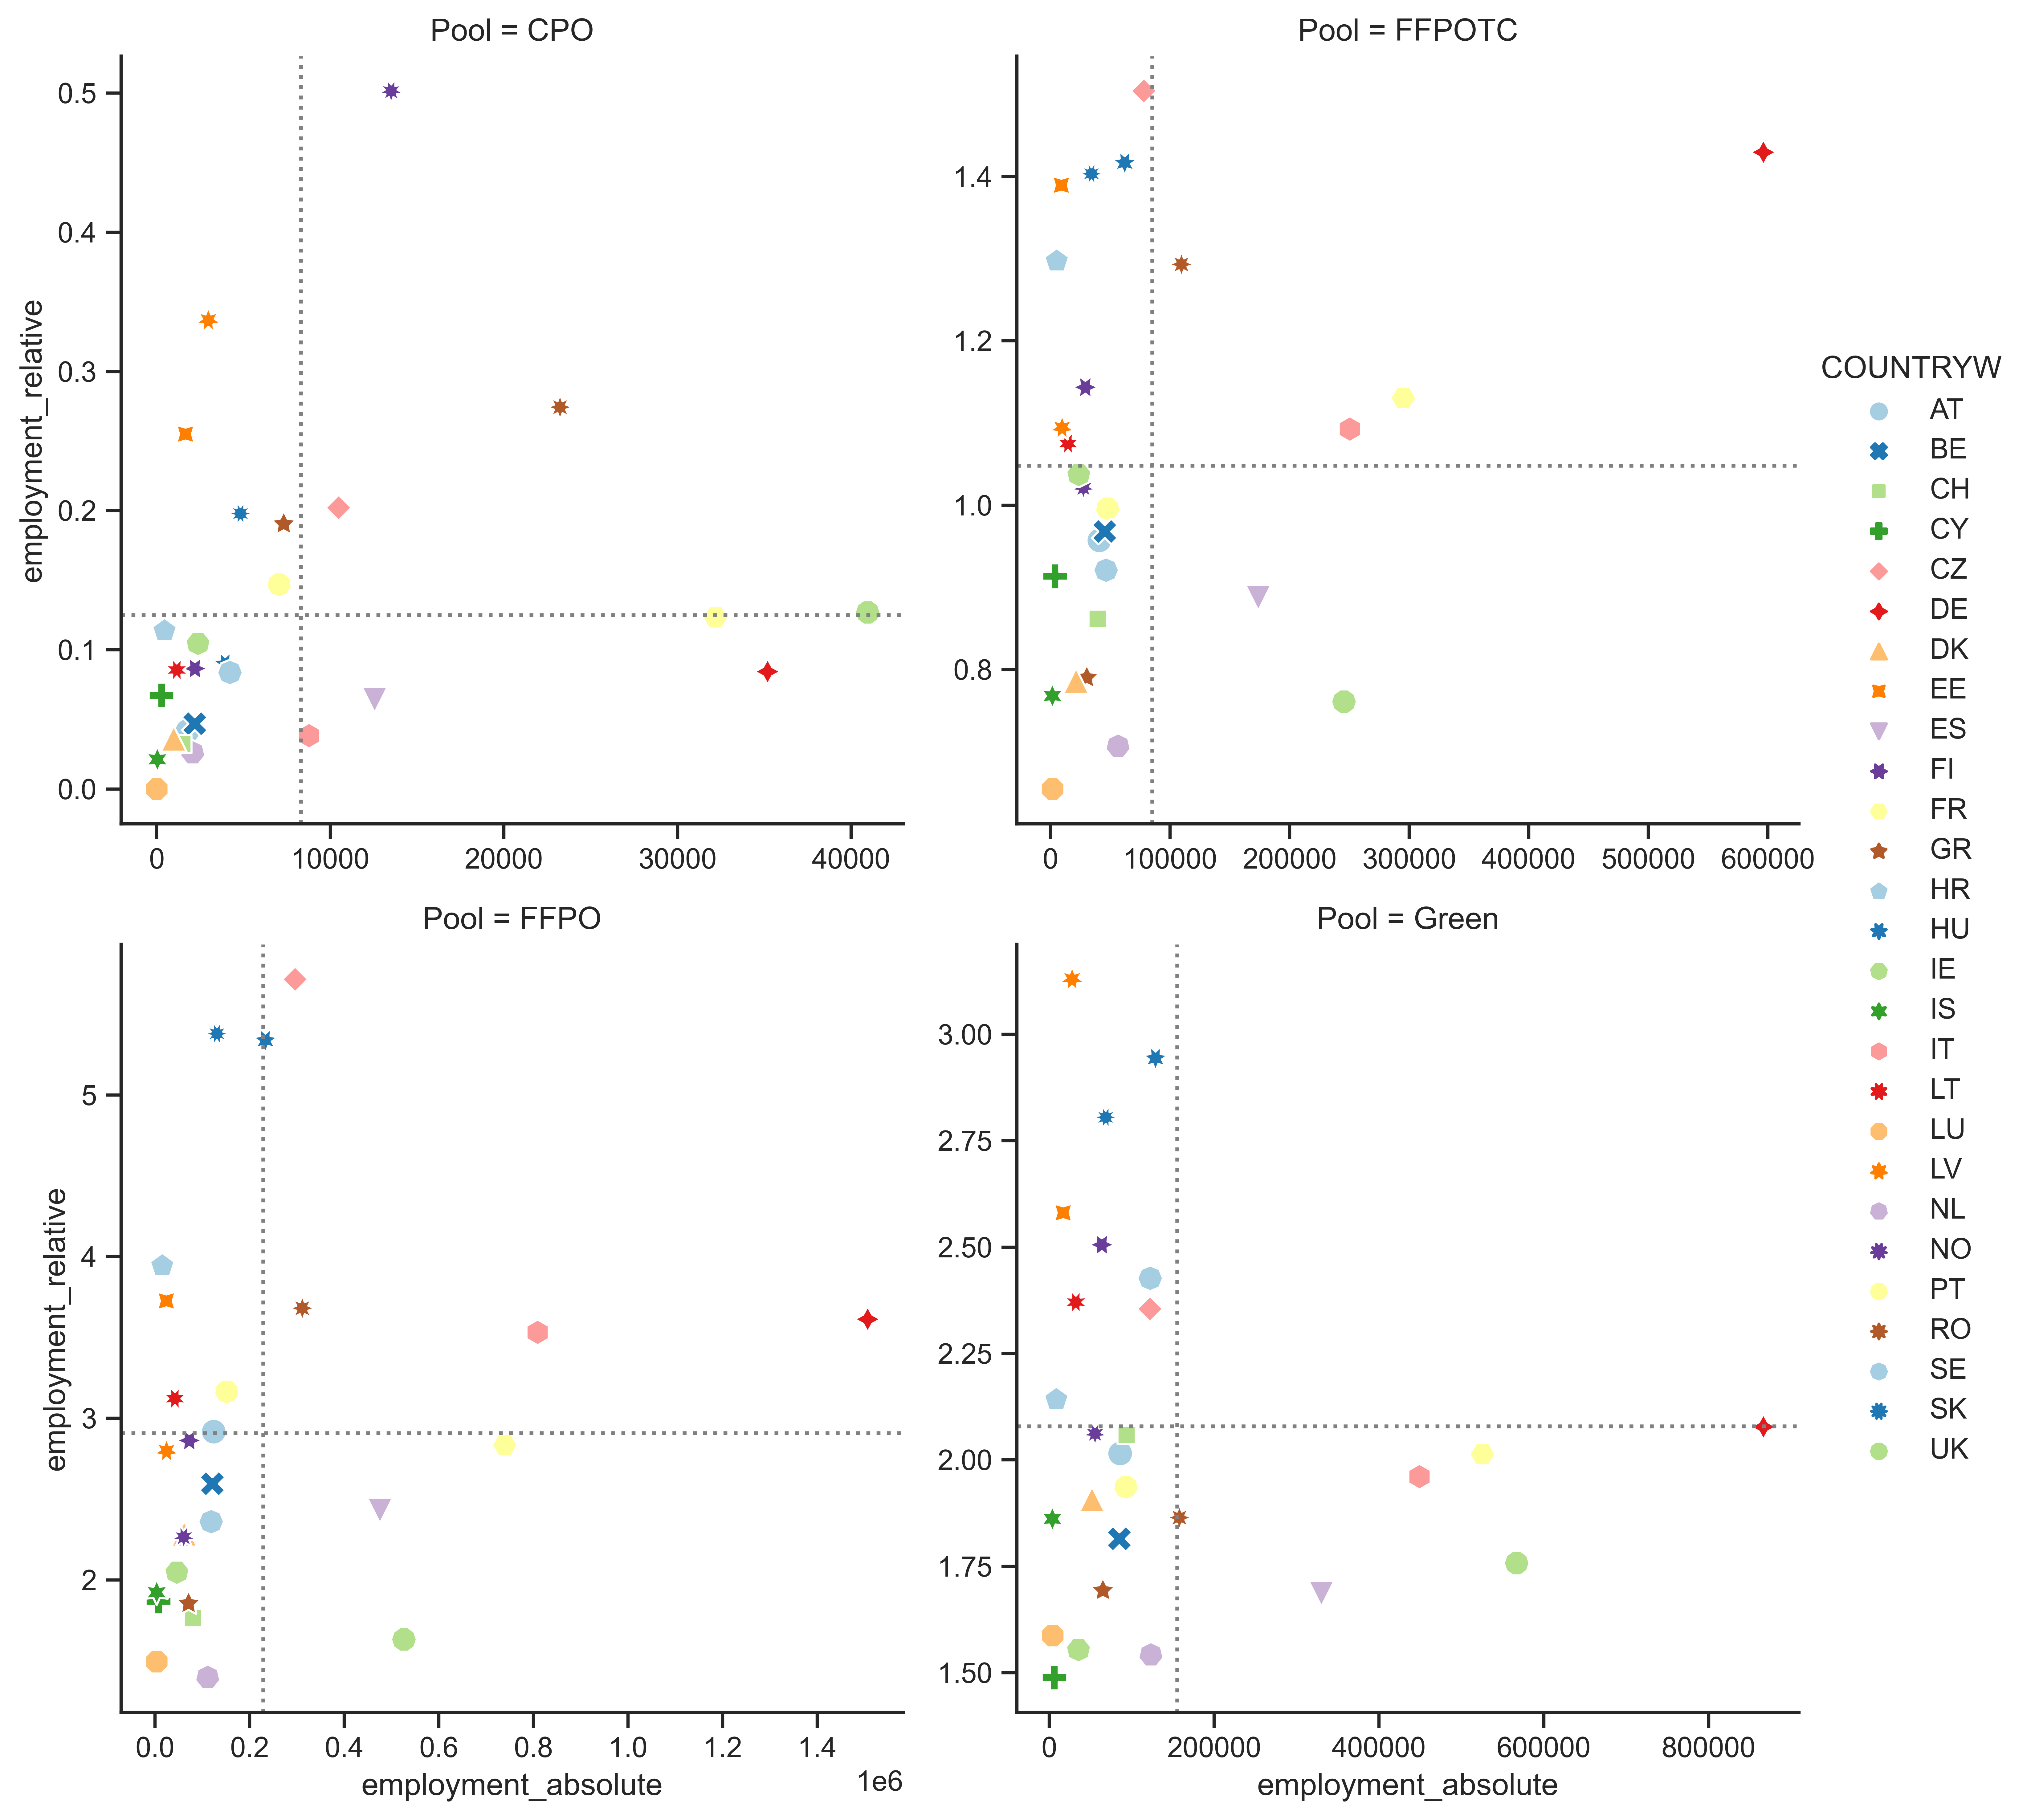

In [34]:
facet_kws = {"sharey": False, "sharex": False}
col_order = ["CPO", "FFPOTC", "FFPO", "Green"]

g = sns.relplot(
    data=df_cnt_share,
    x="employment_absolute",
    y="employment_relative",
    col="Pool",
    col_order=col_order,
    hue="COUNTRYW",
    style="COUNTRYW",
    palette="Paired",
    kind="scatter",
    col_wrap=2,
    s=100,
    facet_kws=facet_kws,
)

# annotate means
for ax, pool in zip(g.axes, col_order):
    x_mean = country_means.loc[pool, "employment_absolute"]
    y_mean = country_means.loc[pool, "employment_relative"]

    ax.axvline(x_mean, color="grey", linestyle=":")
    ax.axhline(y_mean, color="grey", linestyle=":")

# save
out_path = os.path.join(
    useful_paths.figure_dir,
    "03_eulfs",
    "2019",
    "employment_shares_by_country",
    "transition_risk_indicator.{}",
)
plt.savefig(
    out_path.format("png"),
    dpi=300,
    bbox_inches="tight",
)

df_cnt_share.to_csv(out_path.format("csv"))

In [35]:
df_res_sl = df_res.loc[(new_labels), :]
df_res_sl.divide(df_res_sl.sum()) * 100

,employment
share_type,
CPO,1.74
FFPOTC,17.83
FFPO,47.92
Green,32.51


#### Shares by sociodemographic variables

Degree of urbanisation (DEGURBA)

1 Cities (Densely-populated area)
2 Towns and suburbs (Intermediate density area)
3 Rural area (Thinly-populated area)

Gender (SEX)

1 Male
2 Female

Level of education
L Low: Lower secondary
M Medium: Upper secondary
H High: Third level

In [37]:
y = "SEX"

for x in new_labels:
    f, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(data=df, x=y, y=x, order=None, estimator=np.sum, ci=None, color="Grey")

    # calculate country-level percentage
    sum_across_cnt_share = df.groupby(y)[x].sum()
    sum_across_cnt = df.groupby(y)["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    order = sum_across_cnt_share.sort_values(ascending=False).index
    percentages = ind_share.reindex(order).multiply(100).round(1)
    percent_labels = ["{}%".format(l) for l in percentages]

    # show the percentage within sector
    ax.bar_label(ax.containers[0], labels=percent_labels, padding=1)

    ax.ticklabel_format(useOffset=False, style="plain", axis="y")
    ax.grid(axis="y", linestyle="--", zorder=0)
    sns.despine()
    plt.tight_layout()
    out_dir = os.path.join(
        useful_paths.figure_dir, "03_eulfs", "2019", "employment_by_{}".format(y)
    )
    utils.ccdir(out_dir)
    fname = "{}_by_{}_absolute.png".format(x, y)
    plt.savefig(os.path.join(out_dir, fname), dpi=150)
    plt.close(f)

In [ ]:
meanprops = {
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": "3",
}

In [ ]:
f, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="COUNTRYW",
    y="annual_earnings",
    hue="category_sl",
    fliersize=1,
    showmeans=True,
    meanprops=meanprops,
    ax=ax,
)

ax.grid(axis="y", linestyle="--", zorder=0)
ax.set_ylabel("Annual earnings [€ (2019)]")
ax.set_xlabel(None)

sns.despine()

In [ ]:
f, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="COUNTRYW",
    y="annual_earnings",
    hue="category_slt",
    fliersize=1,
    showmeans=True,
    meanprops=meanprops,
    ax=ax,
)

ax.grid(axis="y", linestyle="--", zorder=0)
ax.set_ylabel("Annual earnings [€ (2019)]")
ax.set_xlabel(None)

sns.despine()

In [ ]:
def weighted_mean(x):
    np.average(x, weights=x.COEFF)


# df.groupby("DEGURBA").aggregate({"share_brown_sl": weighted_mean})

In [ ]:
x_vars = ["share_green", "share_brown_sl", "share_brown_slt"]
y = "NACE1D_label"
hues = ["HATLEV1D", "DEGURBA", "SEX"]
hue_orders = [["H", "M", "L"], ["1", "2", "3"], ["1", "2"]]

for x in x_vars:
    for hue, hue_order in zip(hues, hue_orders):
        f, ax = plt.subplots(figsize=(10, 7))
        sns.pointplot(
            data=df,
            x=x,
            y=y,
            hue=hue,
            hue_order=hue_order,
            order=df.groupby(y)[x].mean().sort_values(ascending=False).index.values,
            color=".5",
            ci="sd",
            join=False,
            dodge=0.5,
            errwidth=1,
            # capsize=0.5,
            scale=0.7,
        )

        ax.set_xlim(0, 0.7)
        ax.grid(axis="x", linestyle="--", zorder=0)
        sns.despine()

        plt.tight_layout()
        plt.savefig(
            os.path.join(
                useful_paths.figure_dir,
                "03_eulfs",
                "2019",
                "employment_shares_by_industry",
                "grouped_by_industry_only",
                "{}_by_{}_and_{}.png".format(x, y, hue),
            ),
            dpi=150,
        )
        plt.close(f)

NOTE:
`share_green` precisely equals `COEFF_share_green_relative`

In [ ]:
np.isclose(df.share_green, df.COEFF_share_green_relative).all()

In [ ]:
df.groupby("DEGURBA").describe()

In [ ]:
group_var = "DEGURBA"
num_var = "share_brown_sl"
# sns.boxplot(x=df[group_var].astype(int), y=df[num_var])
sns.pointplot(
    x=df[group_var].astype(int),
    y=df[num_var],
    hue=df["HATLEV1D"].astype(str),
    ci="sd",
    dodge=True,
)

In [ ]:
x = "HATLEV1D"
y = "share_green"
hue = "SEX"
order = ["L", "M", "H"]
df2 = df.dropna(subset=[x])
sns.pointplot(
    x=df2[x].astype(str),
    y=df2[y],
    hue=df2[hue],
    dodge=True,
    palette="Greys",
    ci="sd",
    order=order,
)